# EECE 5644 Final Project: Malaria Detection from Cell Images using Handcrafted Features and Traditional ML Classifiers

**Author**: Suk Jin Mun
**Course**: EECE 5644 — Introduction to Machine Learning (Spring 2026)
**Date**: April 2026

This notebook implements the complete pipeline for the final project. The task is supervised binary classification of red blood cell images as parasitized or uninfected, using the NIH Malaria Cell Images Dataset from Kaggle. The images were collected from thin blood smear slides at Chittagong Medical College Hospital in Bangladesh and annotated by an expert slide reader; see Rajaraman et al. (2018) for the original dataset description. We extract handcrafted color and texture features from each cell, train and compare seven classical machine learning classifiers, perform hyperparameter tuning, and analyze which feature category drives classification. Following the professor's feedback on the proposal, we also train a small convolutional neural network as a deep learning baseline so that the classical results can be benchmarked against an end-to-end learned model.

## 1. Colab Setup

This notebook is designed to be run in Google Colab with a GPU runtime. The dataset is expected to be uploaded as `archive.zip` to Google Drive at the path configured below. The first cell mounts Drive, copies the zip into the Colab session storage, and unzips it. All subsequent cells read images from the local Colab filesystem rather than from Drive, which is much faster than reading 27,558 small files over the Drive API.

In [1]:
# Detect Colab and mount Google Drive.
import os
import sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print('mounted Google Drive at /content/drive')
else:
    print('not in Colab; assuming the data folder is already accessible')

Mounted at /content/drive
mounted Google Drive at /content/drive


In [2]:
# Configure paths. Edit DRIVE_ZIP_PATH to point to where you uploaded archive.zip on Drive.
DRIVE_PROJECT_DIR = '/content/drive/MyDrive/EECE5664/final_project'
DRIVE_ZIP_PATH = os.path.join(DRIVE_PROJECT_DIR, 'archive.zip')
DRIVE_FEATURES_DIR = os.path.join(DRIVE_PROJECT_DIR, 'features')
DRIVE_MODELS_DIR = os.path.join(DRIVE_PROJECT_DIR, 'models')
DRIVE_OUTPUTS_DIR = os.path.join(DRIVE_PROJECT_DIR, 'outputs')

LOCAL_DATA_DIR = '/content/cell_images'
LOCAL_PARASITIZED = os.path.join(LOCAL_DATA_DIR, 'Parasitized')
LOCAL_UNINFECTED = os.path.join(LOCAL_DATA_DIR, 'Uninfected')

if IN_COLAB:
    os.makedirs(DRIVE_FEATURES_DIR, exist_ok=True)
    os.makedirs(DRIVE_MODELS_DIR, exist_ok=True)
    os.makedirs(DRIVE_OUTPUTS_DIR, exist_ok=True)

print(f'drive zip path:     {DRIVE_ZIP_PATH}')
print(f'local data dir:     {LOCAL_DATA_DIR}')
print(f'drive features dir: {DRIVE_FEATURES_DIR}')
print(f'drive models dir:   {DRIVE_MODELS_DIR}')
print(f'drive outputs dir:  {DRIVE_OUTPUTS_DIR}')

drive zip path:     /content/drive/MyDrive/EECE5664/final_project/archive.zip
local data dir:     /content/cell_images
drive features dir: /content/drive/MyDrive/EECE5664/final_project/features
drive models dir:   /content/drive/MyDrive/EECE5664/final_project/models
drive outputs dir:  /content/drive/MyDrive/EECE5664/final_project/outputs


In [3]:
# Copy the zip from Drive into the Colab session and extract it. This is much faster
# than reading 27k small files over the Drive API on every step.
import shutil
import zipfile
import time

if IN_COLAB and not os.path.exists(LOCAL_PARASITIZED):
    if not os.path.exists(DRIVE_ZIP_PATH):
        raise FileNotFoundError(
            f'archive.zip not found at {DRIVE_ZIP_PATH}. Upload it to Google Drive '
            f'at the path above, then re-run this cell.'
        )
    print(f'copying {DRIVE_ZIP_PATH} -> /content/archive.zip ...')
    t0 = time.time()
    shutil.copy(DRIVE_ZIP_PATH, '/content/archive.zip')
    print(f'  copy done in {time.time()-t0:.1f}s')

    print('extracting /content/archive.zip -> /content/ ...')
    t0 = time.time()
    with zipfile.ZipFile('/content/archive.zip', 'r') as zf:
        zf.extractall('/content/')
    print(f'  extract done in {time.time()-t0:.1f}s')

    # The Kaggle archive nests cell_images one level deep
    if not os.path.exists(LOCAL_PARASITIZED):
        nested = '/content/cell_images/cell_images'
        if os.path.exists(nested):
            for sub in ['Parasitized', 'Uninfected']:
                src = os.path.join(nested, sub)
                dst = os.path.join(LOCAL_DATA_DIR, sub)
                if os.path.exists(src) and not os.path.exists(dst):
                    shutil.move(src, dst)

assert os.path.exists(LOCAL_PARASITIZED), f'missing {LOCAL_PARASITIZED}'
assert os.path.exists(LOCAL_UNINFECTED), f'missing {LOCAL_UNINFECTED}'
print(f'parasitized files: {len(os.listdir(LOCAL_PARASITIZED))}')
print(f'uninfected files:  {len(os.listdir(LOCAL_UNINFECTED))}')

copying /content/drive/MyDrive/EECE5664/final_project/archive.zip -> /content/archive.zip ...
  copy done in 9.2s
extracting /content/archive.zip -> /content/ ...
  extract done in 6.4s
parasitized files: 13780
uninfected files:  13780


## 2. Imports

In [4]:
import os
import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.io import imread
from skimage.transform import resize as sk_resize
from skimage.color import rgb2hsv, rgb2gray
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import skew

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             classification_report, precision_recall_curve,
                             average_precision_score)
from matplotlib.colors import ListedColormap

from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_style('whitegrid')
print('imports ok')

imports ok


## 3. Configuration

`IMG_SIZE` controls the resize target for handcrafted feature extraction. `RANDOM_STATE` fixes
the train/test split. `SUBSAMPLE_PER_CLASS` is set to `None` to use the entire dataset. Setting
it to a small integer (e.g., `1000`) is useful for quick development runs.

In [5]:
IMG_SIZE = 128
RANDOM_STATE = 42
TEST_SIZE = 0.2
SUBSAMPLE_PER_CLASS = None  # use all images; set to e.g. 1000 for a fast dev run

print(f'IMG_SIZE = {IMG_SIZE}')
print(f'RANDOM_STATE = {RANDOM_STATE}')
print(f'TEST_SIZE = {TEST_SIZE}')
print(f'SUBSAMPLE_PER_CLASS = {SUBSAMPLE_PER_CLASS}')

IMG_SIZE = 128
RANDOM_STATE = 42
TEST_SIZE = 0.2
SUBSAMPLE_PER_CLASS = None


## 4. Exploratory Data Analysis

We list the image files in each class folder, then visualize a sample of cells from each class
and the distribution of original image sizes. The dataset is approximately balanced between the
two classes, which means accuracy is a meaningful evaluation metric and we do not need
class-rebalancing techniques such as SMOTE.

In [6]:
def list_images(folder):
    return sorted([f for f in os.listdir(folder) if f.lower().endswith('.png')])

parasitized_files = list_images(LOCAL_PARASITIZED)
uninfected_files = list_images(LOCAL_UNINFECTED)

print(f'parasitized PNG files: {len(parasitized_files)}')
print(f'uninfected PNG files:  {len(uninfected_files)}')
print(f'total:                 {len(parasitized_files) + len(uninfected_files)}')
print(f'class balance ratio:   {len(parasitized_files) / (len(parasitized_files) + len(uninfected_files)):.4f}')

parasitized PNG files: 13779
uninfected PNG files:  13779
total:                 27558
class balance ratio:   0.5000


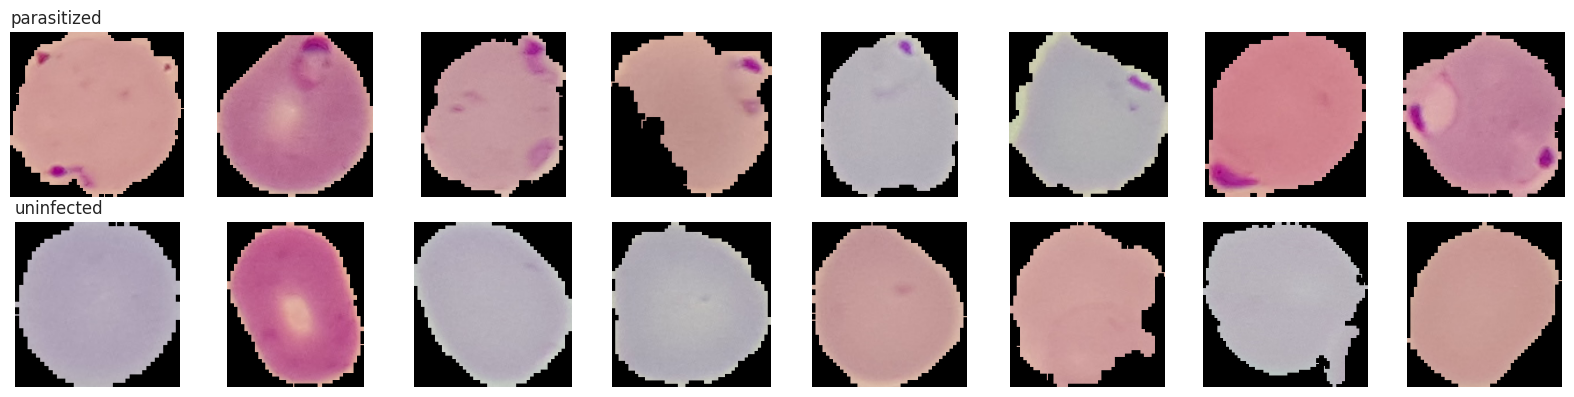

In [7]:
# Visualize 8 samples from each class
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
rng = np.random.default_rng(RANDOM_STATE)
para_sample = rng.choice(parasitized_files, 8, replace=False)
unin_sample = rng.choice(uninfected_files, 8, replace=False)
for i, fname in enumerate(para_sample):
    img = imread(os.path.join(LOCAL_PARASITIZED, fname))
    axes[0, i].imshow(img)
    axes[0, i].set_axis_off()
    if i == 0:
        axes[0, i].set_title('parasitized', loc='left', fontsize=12)
for i, fname in enumerate(unin_sample):
    img = imread(os.path.join(LOCAL_UNINFECTED, fname))
    axes[1, i].imshow(img)
    axes[1, i].set_axis_off()
    if i == 0:
        axes[1, i].set_title('uninfected', loc='left', fontsize=12)
plt.tight_layout()
if IN_COLAB:
    plt.savefig(os.path.join(DRIVE_OUTPUTS_DIR, 'eda_samples.png'), dpi=120, bbox_inches='tight')
plt.show()

sampled sizes in 2.2s


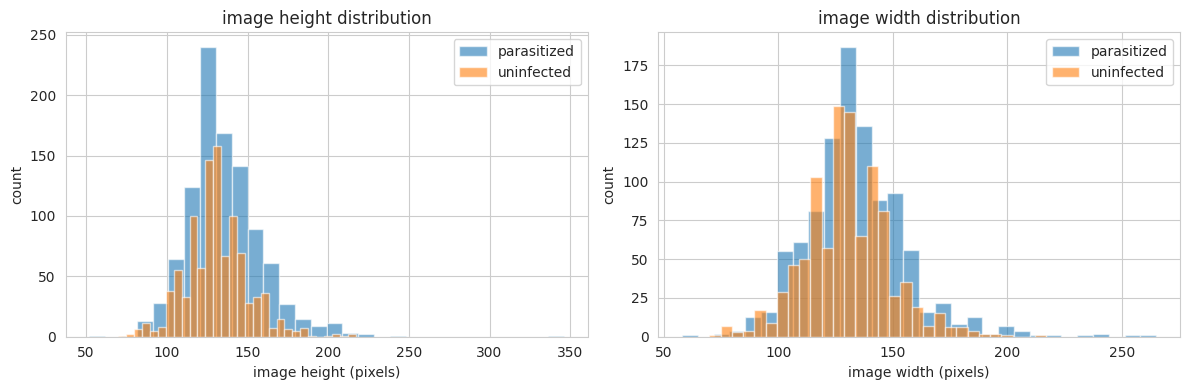

parasitized height: mean 135.5, std 23.4
parasitized width:  mean 133.8, std 22.5
uninfected height:  mean 130.9, std 19.3
uninfected width:   mean 130.2, std 18.7


In [8]:
# Image size distribution from a sample of 1000 images per class
def sample_sizes(folder, files, n=1000):
    rng = np.random.default_rng(RANDOM_STATE)
    chosen = rng.choice(files, min(n, len(files)), replace=False)
    sizes = []
    for f in chosen:
        img = imread(os.path.join(folder, f))
        sizes.append(img.shape[:2])
    return np.array(sizes)

t0 = time.time()
para_sizes = sample_sizes(LOCAL_PARASITIZED, parasitized_files)
unin_sizes = sample_sizes(LOCAL_UNINFECTED, uninfected_files)
print(f'sampled sizes in {time.time()-t0:.1f}s')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(para_sizes[:, 0], bins=30, alpha=0.6, label='parasitized')
axes[0].hist(unin_sizes[:, 0], bins=30, alpha=0.6, label='uninfected')
axes[0].set_xlabel('image height (pixels)')
axes[0].set_ylabel('count')
axes[0].set_title('image height distribution')
axes[0].legend()
axes[1].hist(para_sizes[:, 1], bins=30, alpha=0.6, label='parasitized')
axes[1].hist(unin_sizes[:, 1], bins=30, alpha=0.6, label='uninfected')
axes[1].set_xlabel('image width (pixels)')
axes[1].set_ylabel('count')
axes[1].set_title('image width distribution')
axes[1].legend()
plt.tight_layout()
if IN_COLAB:
    plt.savefig(os.path.join(DRIVE_OUTPUTS_DIR, 'eda_sizes.png'), dpi=120, bbox_inches='tight')
plt.show()

print(f'parasitized height: mean {para_sizes[:,0].mean():.1f}, std {para_sizes[:,0].std():.1f}')
print(f'parasitized width:  mean {para_sizes[:,1].mean():.1f}, std {para_sizes[:,1].std():.1f}')
print(f'uninfected height:  mean {unin_sizes[:,0].mean():.1f}, std {unin_sizes[:,0].std():.1f}')
print(f'uninfected width:   mean {unin_sizes[:,1].mean():.1f}, std {unin_sizes[:,1].std():.1f}')

## 5. Build the File Index and Train/Test Split

We build a list of every image path with its class label, then split the list 80/20 with
stratified sampling so the test set has the same class balance as the training set. The split
is performed on file paths rather than on extracted features so that the deep learning baseline
in Section 14 can use exactly the same train/test partition.

Importantly, the 20% held-out test split is never used inside cross-validation or
hyperparameter tuning; all CV runs and grid searches in Section 10 operate on the 80%
training portion only.


In [9]:
# Build (path, label) pairs. label 1 = parasitized, label 0 = uninfected.
all_paths = []
all_labels = []
for f in parasitized_files:
    all_paths.append(os.path.join(LOCAL_PARASITIZED, f))
    all_labels.append(1)
for f in uninfected_files:
    all_paths.append(os.path.join(LOCAL_UNINFECTED, f))
    all_labels.append(0)
all_paths = np.array(all_paths)
all_labels = np.array(all_labels)

if SUBSAMPLE_PER_CLASS is not None:
    rng = np.random.default_rng(RANDOM_STATE)
    para_idx = np.where(all_labels == 1)[0]
    unin_idx = np.where(all_labels == 0)[0]
    para_keep = rng.choice(para_idx, SUBSAMPLE_PER_CLASS, replace=False)
    unin_keep = rng.choice(unin_idx, SUBSAMPLE_PER_CLASS, replace=False)
    keep = np.concatenate([para_keep, unin_keep])
    all_paths = all_paths[keep]
    all_labels = all_labels[keep]
    print(f'subsampled to {len(all_paths)} images ({SUBSAMPLE_PER_CLASS} per class)')

paths_train, paths_test, y_train, y_test = train_test_split(
    all_paths, all_labels, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=all_labels
)
print(f'training set: {len(paths_train)} images, train parasitized ratio = {y_train.mean():.4f}')
print(f'test set:     {len(paths_test)} images,  test parasitized ratio  = {y_test.mean():.4f}')

training set: 22046 images, train parasitized ratio = 0.5000
test set:     5512 images,  test parasitized ratio  = 0.5000


## 6. Handcrafted Feature Extraction

Each image is resized to `IMG_SIZE x IMG_SIZE` and then converted into a fixed-length numerical
feature vector. We compute two categories of features.

**Color features (18 dimensions).** For each of the three channels in both the RGB color space
and the HSV color space, we compute the mean, standard deviation, and skewness of the pixel
intensities. This gives `3 stats x 3 channels x 2 spaces = 18` color features. Color statistics
are sensitive to the dark stains and pigment changes that mark parasitized cells.

**Texture features (16 dimensions).** We convert each image to grayscale, quantize the
intensities to 32 levels, and compute a gray-level co-occurrence matrix (GLCM) at distance 1
for the four standard angles 0, 45, 90, and 135 degrees. From each angle's GLCM we compute
contrast, correlation, energy, and homogeneity, giving `4 stats x 4 angles = 16` texture
features. Texture statistics capture local intensity patterns that change when a parasite
disrupts the smooth interior of a healthy cell.

The total feature vector has 34 dimensions per image. Feature extraction is the most expensive
step in the pipeline, so we cache the extracted matrices to Drive after the first run.

The 128-pixel resize is chosen to keep GLCM texture computation fast while preserving
enough spatial detail for color statistics, and it matches the spatial scale at which
Molina et al. (2020) operate in the published baseline.


In [10]:
GLCM_LEVELS = 32
GLCM_ANGLES = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
GLCM_PROPS = ['contrast', 'correlation', 'energy', 'homogeneity']

COLOR_FEATURE_NAMES = []
for space in ['rgb', 'hsv']:
    for ch in [0, 1, 2]:
        for stat in ['mean', 'std', 'skew']:
            COLOR_FEATURE_NAMES.append(f'{space}_ch{ch}_{stat}')

TEXTURE_FEATURE_NAMES = []
for prop in GLCM_PROPS:
    for k in range(len(GLCM_ANGLES)):
        TEXTURE_FEATURE_NAMES.append(f'glcm_{prop}_a{k}')

ALL_FEATURE_NAMES = COLOR_FEATURE_NAMES + TEXTURE_FEATURE_NAMES
print(f'total features per image: {len(ALL_FEATURE_NAMES)}')
print(f'  color:   {len(COLOR_FEATURE_NAMES)}')
print(f'  texture: {len(TEXTURE_FEATURE_NAMES)}')

total features per image: 34
  color:   18
  texture: 16


In [11]:
def color_features(img_rgb_uint8):
    # Color statistics in RGB and HSV color spaces.
    img_rgb = img_rgb_uint8.astype(np.float32) / 255.0
    img_hsv = rgb2hsv(img_rgb)
    feats = []
    for img in (img_rgb, img_hsv):
        for ch in range(3):
            c = img[:, :, ch].ravel()
            feats.append(float(c.mean()))
            feats.append(float(c.std()))
            s = skew(c)
            if not np.isfinite(s):
                s = 0.0
            feats.append(float(s))
    return np.array(feats, dtype=np.float32)


def texture_features(img_rgb_uint8):
    # GLCM-based texture statistics from a quantized grayscale image.
    gray = rgb2gray(img_rgb_uint8.astype(np.float32) / 255.0)
    gray_q = np.clip((gray * (GLCM_LEVELS - 1)).round().astype(np.uint8), 0, GLCM_LEVELS - 1)
    glcm = graycomatrix(gray_q, distances=[1], angles=GLCM_ANGLES,
                        levels=GLCM_LEVELS, symmetric=True, normed=True)
    feats = []
    for prop in GLCM_PROPS:
        v = graycoprops(glcm, prop)[0]  # shape (len(angles),)
        feats.extend(v.tolist())
    return np.array(feats, dtype=np.float32)


def extract_one(path):
    img = imread(path)
    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)
    if img.shape[-1] == 4:
        img = img[..., :3]
    img_resized = sk_resize(img, (IMG_SIZE, IMG_SIZE), preserve_range=True, anti_aliasing=True)
    img_resized = img_resized.astype(np.uint8)
    cf = color_features(img_resized)
    tf = texture_features(img_resized)
    return np.concatenate([cf, tf])

print('feature functions defined')

feature functions defined


In [12]:
def extract_features_for_paths(paths, label, cache_path):
    # Extract features for every path, with disk caching keyed by cache_path.
    if cache_path is not None and os.path.exists(cache_path):
        print(f'  loading cached features from {cache_path}')
        data = np.load(cache_path)
        return data['X']
    n = len(paths)
    X = np.zeros((n, len(ALL_FEATURE_NAMES)), dtype=np.float32)
    t0 = time.time()
    report_every = max(1, n // 20)
    for i, p in enumerate(paths):
        X[i] = extract_one(p)
        if (i + 1) % report_every == 0 or i == n - 1:
            elapsed = time.time() - t0
            rate = (i + 1) / elapsed
            eta = (n - i - 1) / rate
            print(f'  [{label}] {i+1:>6}/{n}  '
                  f'{rate:.1f} img/s  elapsed {elapsed:.0f}s  eta {eta:.0f}s')
    if cache_path is not None:
        os.makedirs(os.path.dirname(cache_path), exist_ok=True)
        np.savez(cache_path, X=X)
        print(f'  saved cache to {cache_path}')
    return X

cache_train = os.path.join(DRIVE_FEATURES_DIR, f'features_train_{IMG_SIZE}_sub{SUBSAMPLE_PER_CLASS}.npz') if IN_COLAB else None
cache_test = os.path.join(DRIVE_FEATURES_DIR, f'features_test_{IMG_SIZE}_sub{SUBSAMPLE_PER_CLASS}.npz') if IN_COLAB else None

print('extracting training features ...')
X_train_raw = extract_features_for_paths(paths_train, 'train', cache_train)
print('extracting test features ...')
X_test_raw = extract_features_for_paths(paths_test, 'test', cache_test)
print(f'X_train_raw shape: {X_train_raw.shape}')
print(f'X_test_raw shape:  {X_test_raw.shape}')

extracting training features ...
  [train]   1102/22046  65.2 img/s  elapsed 17s  eta 321s
  [train]   2204/22046  65.8 img/s  elapsed 34s  eta 302s
  [train]   3306/22046  66.0 img/s  elapsed 50s  eta 284s
  [train]   4408/22046  65.8 img/s  elapsed 67s  eta 268s
  [train]   5510/22046  66.0 img/s  elapsed 84s  eta 251s
  [train]   6612/22046  65.8 img/s  elapsed 100s  eta 234s
  [train]   7714/22046  65.7 img/s  elapsed 117s  eta 218s
  [train]   8816/22046  65.5 img/s  elapsed 135s  eta 202s
  [train]   9918/22046  65.4 img/s  elapsed 152s  eta 185s
  [train]  11020/22046  65.4 img/s  elapsed 169s  eta 169s
  [train]  12122/22046  65.4 img/s  elapsed 185s  eta 152s
  [train]  13224/22046  65.3 img/s  elapsed 202s  eta 135s
  [train]  14326/22046  65.3 img/s  elapsed 219s  eta 118s
  [train]  15428/22046  65.2 img/s  elapsed 236s  eta 101s
  [train]  16530/22046  65.2 img/s  elapsed 253s  eta 85s
  [train]  17632/22046  65.2 img/s  elapsed 270s  eta 68s
  [train]  18734/22046  65.2 i

In [13]:
# Show feature dataframe head for a sanity check
df_preview = pd.DataFrame(X_train_raw[:5], columns=ALL_FEATURE_NAMES)
df_preview.insert(0, 'label', y_train[:5])
print('first 5 training rows:')
print(df_preview.round(4).to_string())

first 5 training rows:
   label  rgb_ch0_mean  rgb_ch0_std  rgb_ch0_skew  rgb_ch1_mean  rgb_ch1_std  rgb_ch1_skew  rgb_ch2_mean  rgb_ch2_std  rgb_ch2_skew  hsv_ch0_mean  hsv_ch0_std  hsv_ch0_skew  hsv_ch1_mean  hsv_ch1_std  hsv_ch1_skew  hsv_ch2_mean  hsv_ch2_std  hsv_ch2_skew  glcm_contrast_a0  glcm_contrast_a1  glcm_contrast_a2  glcm_contrast_a3  glcm_correlation_a0  glcm_correlation_a1  glcm_correlation_a2  glcm_correlation_a3  glcm_energy_a0  glcm_energy_a1  glcm_energy_a2  glcm_energy_a3  glcm_homogeneity_a0  glcm_homogeneity_a1  glcm_homogeneity_a2  glcm_homogeneity_a3
0      0        0.4614       0.3887       -0.3086        0.3287       0.2779       -0.2852        0.3606       0.3036       -0.3132        0.5314       0.4751       -0.2199        0.1743       0.1427       -0.3765        0.4614       0.3887       -0.3086            4.0581            7.6815            3.9730            7.2754               0.9770               0.9563               0.9775               0.9586        

## 7. Feature Scaling and Preprocessing Rationale

Several of the classifiers we will use are sensitive to feature scale (logistic regression, KNN,
SVM with the RBF kernel). We fit a `StandardScaler` on the training matrix only and apply the
same transform to the test matrix. Tree-based models (decision tree, random forest, XGBoost)
are scale-invariant but using the scaled features for them as well does not hurt and keeps the
pipeline simple.

**Preprocessing decisions and why they are appropriate for this dataset.** We briefly record
the preprocessing choices that are relevant on tabular datasets but do not apply to this image
dataset, so the absence of those steps is an explicit decision rather than an oversight.

- **Missing-value imputation is not applied.** The raw inputs are PNG image files, not CSV
  rows with nullable fields. Every successfully-read image produces a complete 34-dimensional
  feature vector by construction. The image-data analogue of a missing value is a corrupted or
  unreadable image file; the NIH-curated Kaggle dataset does not contain any such files in our
  experience, and the feature extraction loop will raise an exception on the first unreadable
  file rather than silently producing `NaN` features.
- **Class rebalancing is not applied.** The two classes are already balanced at 13,779
  parasitized and 13,779 uninfected cells, a ratio of 0.5. Oversampling techniques such as
  SMOTE, undersampling, or class-weighted losses are not required and could introduce
  artifacts that harm the evaluation.
- **Categorical encoding is not applied.** All 34 features are already numeric (color and
  texture summary statistics), so there are no categorical variables to one-hot encode.
- **Data augmentation is not applied to the classical pipeline.** Handcrafted color
  statistics (mean, standard deviation, skewness) are invariant to horizontal flips and
  90-degree rotations, so standard image augmentations would not change the feature
  values; they would only increase feature-extraction time. For the CNN baseline in
  Section 14 augmentation is a reasonable extension and is noted in the future-work
  section.
- **A patient-grouped split is not feasible.** The Kaggle release does not expose the
  originating patient or slide ID for each image, so a grouped-by-patient split that
  would prevent cells from the same slide appearing in both the train and test sets
  cannot be constructed from this distribution. This is a real limitation for clinical
  generalization and is noted in the future-work section; it is also why we flag
  revalidation on a patient-level split as a deployment prerequisite in the discussion.
- **Feature scaling during cross-validated tuning is handled by a sklearn `Pipeline`.** For
  the classical model training in Section 8 we use the globally-fitted `StandardScaler` above,
  which is correct because that section uses a single held-out test split and the scaler is
  fit on the training portion only. For the hyperparameter tuning in Section 10 we instead
  wrap the scaler and the classifier in a sklearn `Pipeline`, so each fold of the five-fold
  stratified cross-validation learns its own scaling parameters on its own training fold.
  This avoids the minor leakage that would arise if the global scaler were reused inside
  the CV loop.

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)
print(f'X_train mean (should be ~0): {X_train.mean():.4f}, std (should be ~1): {X_train.std():.4f}')
print(f'X_test mean (small): {X_test.mean():.4f}, std (close to 1): {X_test.std():.4f}')

# Save the fitted scaler so new inputs can be preprocessed with the same transform at
# inference time without needing to re-run feature extraction.
if IN_COLAB:
    scaler_path = os.path.join(DRIVE_MODELS_DIR, 'standard_scaler.joblib')
    joblib.dump(scaler, scaler_path)
    print(f'saved fitted StandardScaler to {scaler_path}')

X_train mean (should be ~0): 0.0000, std (should be ~1): 1.0000
X_test mean (small): 0.0096, std (close to 1): 0.9998
saved fitted StandardScaler to /content/drive/MyDrive/EECE5664/final_project/models/standard_scaler.joblib


## 8. Train Seven Classical Models with Default Hyperparameters (and a Dummy Baseline)

We train seven classifiers using the default hyperparameters of each scikit-learn / XGBoost
class, plus a `DummyClassifier` (majority-class predictor) as a sanity-check floor. The
project plan originally proposed six models; we additionally include Gaussian Naive Bayes,
which was taught in the lectures on Naive Bayes and which Molina et al. (2020) also used.
The seven real models span generative (Naive Bayes), linear (LogReg), instance-based (KNN),
kernel (SVM-RBF), and tree-based (DecisionTree, Random Forest, XGBoost) families. The dummy
row serves the exact role Lecture 16 demonstrated with its "always-negative classifier"
example: any real model should comfortably beat the majority-class baseline, otherwise the
model has not actually learned anything.

Regularization is present implicitly across the list: Logistic Regression uses L2 by default
(the regularization strength `C=1`), and the tree-based models control capacity via the
`max_depth`, `min_samples_leaf`, and `n_estimators` knobs that we sweep in the grid search in
Section 10, which matches the regularization framing from the logistic regression lectures.

- **Logistic Regression** is a linear baseline whose parameters are estimated by maximum
  likelihood with L2 regularization. It is taught directly in the logistic regression lectures
  and connects to the MLE framework covered in class. It is sensitive to feature scale.
- **K-Nearest Neighbors (K=5)** is an instance-based classifier that predicts the label by
  majority vote over the five closest training points in the standardized feature space. It is
  the topic of the KNN lecture and is sensitive to feature scale.
- **Support Vector Machine with the RBF kernel** finds a nonlinear decision boundary that
  maximizes the margin between the two classes in a kernel-induced feature space. It is
  included because the project specification explicitly lists SVM as one of the example models
  to try, and it provides a strong nonlinear baseline against the other classifiers. It is
  sensitive to feature scale.
- **Decision Tree** recursively splits the feature space on single-feature thresholds by
  maximizing information gain. It is the topic of the decision tree lecture and is fully
  interpretable but prone to overfitting without regularization.
- **Random Forest (200 trees)** is an ensemble of decorrelated trees trained on bootstrapped
  samples of the training set. We include it as a natural ensemble extension of the single
  decision tree covered in Lecture 9, which reduces variance at the cost of interpretability.
- **XGBoost (200 trees)** is a gradient-boosted tree ensemble in which each new tree is fit to
  the residual errors of the current ensemble. It is included because the project specification
  explicitly lists gradient boosting as one of the example models to try, and it is typically
  the strongest classical model on tabular feature sets of this size.
- **Gaussian Naive Bayes** is a generative classifier that assumes conditional independence of
  features given the class and models each feature as Gaussian. It is taught directly in the
  Naive Bayes lecture and matches the classifier set used by Molina et al. It is
  scale-invariant and very fast to train.

The metrics reported are accuracy, precision, recall, F1, and AUC, all computed on the held-out
test set. Cross-validation is used in Section 10 for hyperparameter tuning.

We rank models by test F1 rather than by accuracy. On this balanced dataset the two
metrics are nearly identical, but F1 is reported for consistency with the deployment
evaluation framing, where recall on the parasitized class matters more clinically than
raw accuracy.


In [15]:
def evaluate_model(model, name, X_tr, y_tr, X_te, y_te):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    fit_time = time.time() - t0
    y_pred = model.predict(X_te)
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_te)
    else:
        y_score = y_pred.astype(float)
    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred),
        'recall': recall_score(y_te, y_pred),
        'f1': f1_score(y_te, y_pred),
        'auc': roc_auc_score(y_te, y_score),
        'fit_time_s': fit_time,
    }
    return model, metrics, y_pred, y_score

print('evaluate_model defined')

evaluate_model defined


In [16]:
classifiers = {
    'Dummy (majority)': DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE),
    'LogReg': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM-RBF': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=200, eval_metric='logloss',
                             n_jobs=-1, random_state=RANDOM_STATE),
    'GaussianNB': GaussianNB(),
}

results = {}
for name, clf in classifiers.items():
    print(f'training {name} ...')
    model, metrics, y_pred, y_score = evaluate_model(clf, name, X_train, y_train, X_test, y_test)
    results[name] = {'model': model, 'metrics': metrics, 'y_pred': y_pred, 'y_score': y_score}
    print(f'  acc={metrics["accuracy"]:.4f}  f1={metrics["f1"]:.4f}  '
          f'auc={metrics["auc"]:.4f}  fit_time={metrics["fit_time_s"]:.1f}s')

# Persist every trained classical model to Drive so the notebook run produces tangible
# artifacts that can be loaded later for inference without retraining.
if IN_COLAB:
    for name, r in results.items():
        path = os.path.join(DRIVE_MODELS_DIR, f'model_{name}.joblib')
        joblib.dump(r['model'], path)
    print(f'saved {len(results)} classical models to {DRIVE_MODELS_DIR}')

training Dummy (majority) ...
  acc=0.5000  f1=0.0000  auc=0.5000  fit_time=0.0s
training LogReg ...
  acc=0.8919  f1=0.8916  auc=0.9521  fit_time=2.4s
training KNN ...
  acc=0.8656  f1=0.8679  auc=0.9284  fit_time=0.0s
training SVM-RBF ...
  acc=0.9305  f1=0.9301  auc=0.9761  fit_time=53.1s
training DecisionTree ...
  acc=0.9062  f1=0.9063  auc=0.9062  fit_time=1.9s
training RandomForest ...
  acc=0.9369  f1=0.9371  auc=0.9829  fit_time=3.8s
training XGBoost ...
  acc=0.9421  f1=0.9416  auc=0.9845  fit_time=1.0s
training GaussianNB ...
  acc=0.7645  f1=0.7612  auc=0.8255  fit_time=0.0s
saved 8 classical models to /content/drive/MyDrive/EECE5664/final_project/models


In [17]:
# Tabular metrics for all classifiers plus the dummy baseline
metrics_df = pd.DataFrame([results[n]['metrics'] for n in classifiers.keys()])
metrics_df = metrics_df.set_index('model')
print('test set metrics for the classical classifiers plus the dummy baseline:')
print(metrics_df.round(4).to_string())
if IN_COLAB:
    metrics_df.to_csv(os.path.join(DRIVE_OUTPUTS_DIR, 'classical_metrics_default.csv'))

test set metrics for the classical classifiers plus the dummy baseline:
                  accuracy  precision  recall      f1     auc  fit_time_s
model                                                                    
Dummy (majority)    0.5000     0.0000  0.0000  0.0000  0.5000      0.0013
LogReg              0.8919     0.8942  0.8890  0.8916  0.9521      2.3514
KNN                 0.8656     0.8529  0.8835  0.8679  0.9284      0.0017
SVM-RBF             0.9305     0.9361  0.9242  0.9301  0.9761     53.1112
DecisionTree        0.9062     0.9052  0.9075  0.9063  0.9062      1.9192
RandomForest        0.9369     0.9334  0.9409  0.9371  0.9829      3.8346
XGBoost             0.9421     0.9508  0.9325  0.9416  0.9845      1.0181
GaussianNB          0.7645     0.7720  0.7507  0.7612  0.8255      0.0088


### Logistic regression coefficient interpretation

Lecture 16 emphasized that one of the advantages of linear models is that their learned
coefficients can be read directly to see which features the model relied on most heavily.
We extract the coefficient vector from the trained logistic regression and plot the top 15
features by absolute coefficient magnitude, colored by feature category (color vs texture).
This is a second, linear-model-based take on feature importance to complement the
tree-based `feature_importances_` analysis later in Section 11.

top 10 logistic regression coefficients by |coef|:
     feature  coefficient category
 rgb_ch1_std     7.015180    color
hsv_ch2_skew     6.588703    color
rgb_ch0_skew    -5.706150    color
 hsv_ch1_std     4.369605    color
rgb_ch1_mean    -3.650079    color
rgb_ch1_skew    -3.644063    color
 rgb_ch0_std    -3.613317    color
rgb_ch2_skew     3.095067    color
hsv_ch1_skew     2.961082    color
rgb_ch2_mean     2.831901    color


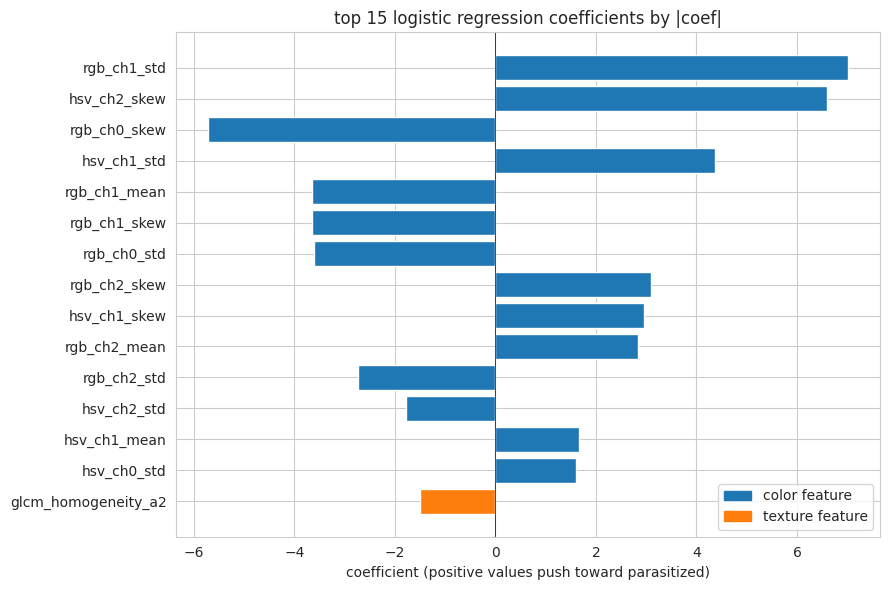

In [18]:
# Plot top-15 logistic regression coefficients by |coef|
logreg_model = results['LogReg']['model']
if hasattr(logreg_model, 'coef_'):
    coefs = logreg_model.coef_[0]  # shape (n_features,)
    categories = (['color'] * len(COLOR_FEATURE_NAMES)
                  + ['texture'] * len(TEXTURE_FEATURE_NAMES))
    coef_df = pd.DataFrame({
        'feature': ALL_FEATURE_NAMES,
        'coefficient': coefs,
        'abs_coef': np.abs(coefs),
        'category': categories,
    }).sort_values('abs_coef', ascending=False).reset_index(drop=True)

    print('top 10 logistic regression coefficients by |coef|:')
    print(coef_df.head(10)[['feature', 'coefficient', 'category']].to_string(index=False))

    top_n = 15
    top = coef_df.head(top_n)
    colors_bar = ['#1f77b4' if c == 'color' else '#ff7f0e' for c in top['category']]

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(range(top_n), top['coefficient'], color=colors_bar)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top['feature'])
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('coefficient (positive values push toward parasitized)')
    ax.set_title('top 15 logistic regression coefficients by |coef|')
    import matplotlib.patches as mpatches
    ax.legend(handles=[
        mpatches.Patch(color='#1f77b4', label='color feature'),
        mpatches.Patch(color='#ff7f0e', label='texture feature'),
    ], loc='lower right')
    plt.tight_layout()
    if IN_COLAB:
        plt.savefig(os.path.join(DRIVE_OUTPUTS_DIR, 'logreg_coefficients.png'),
                    dpi=120, bbox_inches='tight')
        coef_df.to_csv(os.path.join(DRIVE_OUTPUTS_DIR, 'logreg_coefficients.csv'), index=False)
    plt.show()

## 9. ROC Curves and Confusion Matrix for the Best Classical Model

We plot the receiver operating characteristic curve for all six classifiers on the same axes,
then identify the model with the best test F1 score and display its confusion matrix and full
classification report on both the training and test splits.

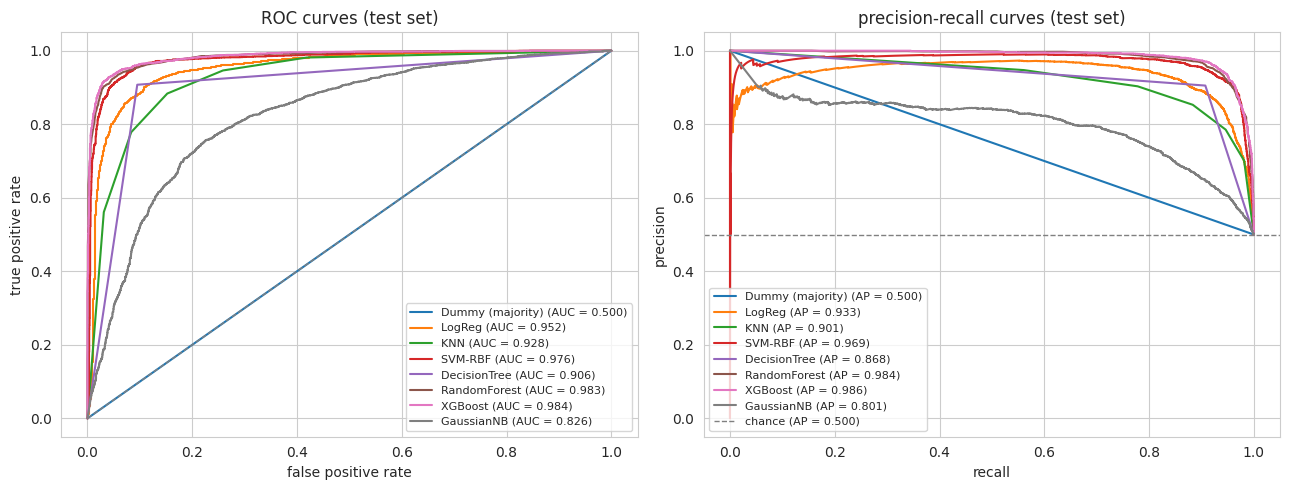

In [19]:
# ROC curves + precision-recall curves side by side. Lecture 17 explicitly taught
# that PR curves are a useful companion to ROC, particularly for applications where
# the positive class matters operationally (medical screening in our case).
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: ROC
ax = axes[0]
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_score'])
    auc_v = r['metrics']['auc']
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc_v:.3f})')
ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')
ax.set_title('ROC curves (test set)')
ax.legend(loc='lower right', fontsize=8)

# Right: Precision-Recall
ax = axes[1]
for name, r in results.items():
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, r['y_score'])
    ap = average_precision_score(y_test, r['y_score'])
    ax.plot(rec_arr, prec_arr, label=f'{name} (AP = {ap:.3f})')
# Chance line = positive class proportion
pos_rate = float(y_test.mean())
ax.axhline(pos_rate, ls='--', color='gray', linewidth=1, label=f'chance (AP = {pos_rate:.3f})')
ax.set_xlabel('recall')
ax.set_ylabel('precision')
ax.set_title('precision-recall curves (test set)')
ax.legend(loc='lower left', fontsize=8)

plt.tight_layout()
if IN_COLAB:
    plt.savefig(os.path.join(DRIVE_OUTPUTS_DIR, 'classical_roc_pr.png'), dpi=120, bbox_inches='tight')
plt.show()

best classical model by test F1: XGBoost


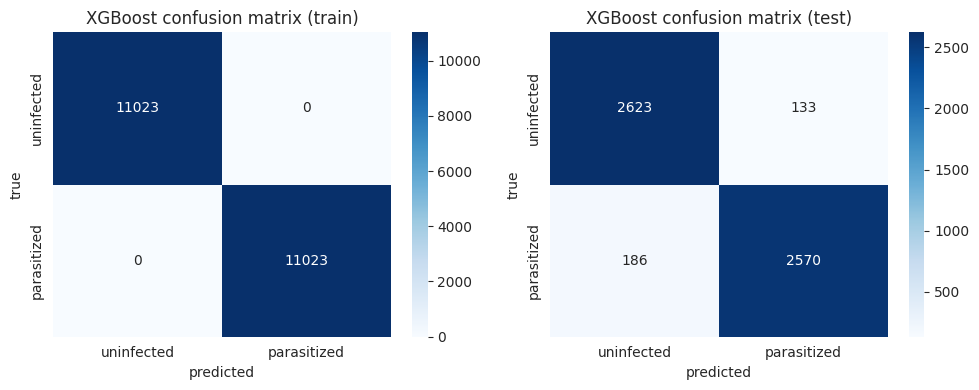


XGBoost training classification report:
              precision    recall  f1-score   support

  uninfected       1.00      1.00      1.00     11023
 parasitized       1.00      1.00      1.00     11023

    accuracy                           1.00     22046
   macro avg       1.00      1.00      1.00     22046
weighted avg       1.00      1.00      1.00     22046

XGBoost test classification report:
              precision    recall  f1-score   support

  uninfected       0.93      0.95      0.94      2756
 parasitized       0.95      0.93      0.94      2756

    accuracy                           0.94      5512
   macro avg       0.94      0.94      0.94      5512
weighted avg       0.94      0.94      0.94      5512



In [20]:
best_name = max(results.keys(), key=lambda n: results[n]['metrics']['f1'])
print(f'best classical model by test F1: {best_name}')
best_model = results[best_name]['model']
y_train_pred = best_model.predict(X_train)
y_test_pred = results[best_name]['y_pred']

cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['uninfected', 'parasitized'],
            yticklabels=['uninfected', 'parasitized'])
axes[0].set_title(f'{best_name} confusion matrix (train)')
axes[0].set_xlabel('predicted')
axes[0].set_ylabel('true')
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['uninfected', 'parasitized'],
            yticklabels=['uninfected', 'parasitized'])
axes[1].set_title(f'{best_name} confusion matrix (test)')
axes[1].set_xlabel('predicted')
axes[1].set_ylabel('true')
plt.tight_layout()
if IN_COLAB:
    plt.savefig(os.path.join(DRIVE_OUTPUTS_DIR, 'classical_best_confusion.png'),
                dpi=120, bbox_inches='tight')
plt.show()

print()
print(f'{best_name} training classification report:')
print(classification_report(y_train, y_train_pred, target_names=['uninfected', 'parasitized']))
print(f'{best_name} test classification report:')
print(classification_report(y_test, y_test_pred, target_names=['uninfected', 'parasitized']))

### A note on classification thresholds

Every probabilistic classifier above is evaluated at the default decision threshold of 0.5.
Lecture 17 showed that the threshold is a free knob that can be slid along the ROC/PR curve
to trade precision for recall without retraining the model. We keep the default threshold in
this report because the project does not specify an asymmetric cost between false positives
and false negatives. In a real deployment for malaria diagnosis the cost of a false negative
(missing an infected cell) is clinically higher than the cost of a false positive (flagging
a healthy cell for re-examination), so the operating point would likely be lowered below 0.5
to favor recall on the parasitized class, at the expense of some precision. The ROC and PR
curves plotted above are exactly the tools that lecture recommended for picking such an
operating point when a cost target is available.

### Error analysis: which cells does the best classical model get wrong?

A confusion matrix gives counts of the two error types but hides what the errors look like.
We now pull out the actual image files for a handful of the best model's false positives
(predicted parasitized, actually uninfected) and false negatives (predicted uninfected,
actually parasitized) and display them. Qualitative inspection of error cases is a standard
interpretability step in classification analysis and often points to the failure modes that
would need to be addressed in a deployment version of the model.

XGBoost made 319 mistakes on 5512 test samples (5.79%)
  false positives (predicted parasitized, actually uninfected): 133
  false negatives (predicted uninfected, actually parasitized): 186


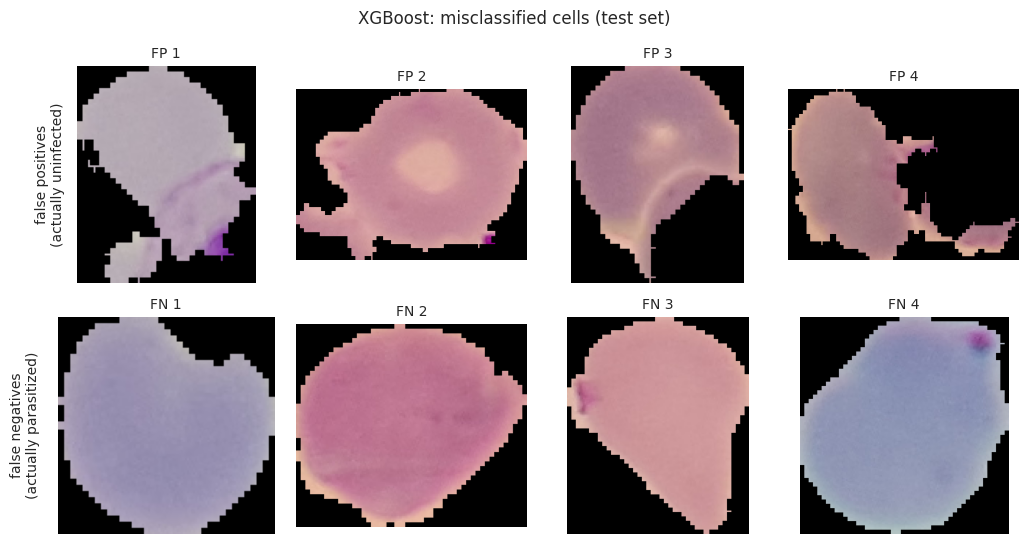

In [21]:
# Error analysis — show misclassified cell images for the best classical model
y_test_pred_best = results[best_name]['y_pred']
errors_mask = (y_test_pred_best != y_test)
fp_idx = np.where((y_test_pred_best == 1) & (y_test == 0))[0]  # predicted parasitized, actually uninfected
fn_idx = np.where((y_test_pred_best == 0) & (y_test == 1))[0]  # predicted uninfected, actually parasitized

total_errors = int(errors_mask.sum())
print(f'{best_name} made {total_errors} mistakes on {len(y_test)} test samples '
      f'({total_errors / len(y_test) * 100:.2f}%)')
print(f'  false positives (predicted parasitized, actually uninfected): {len(fp_idx)}')
print(f'  false negatives (predicted uninfected, actually parasitized): {len(fn_idx)}')

n_show = 4
fp_sample = fp_idx[:n_show]
fn_sample = fn_idx[:n_show]

fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2.6, 5.5))
for i, idx in enumerate(fp_sample):
    img = imread(paths_test[idx])
    axes[0, i].imshow(img)
    axes[0, i].set_axis_off()
    axes[0, i].set_title(f'FP {i+1}', fontsize=10)
for i, idx in enumerate(fn_sample):
    img = imread(paths_test[idx])
    axes[1, i].imshow(img)
    axes[1, i].set_axis_off()
    axes[1, i].set_title(f'FN {i+1}', fontsize=10)
axes[0, 0].text(-0.15, 0.5, 'false positives\n(actually uninfected)',
                transform=axes[0, 0].transAxes, rotation=90, va='center', ha='center', fontsize=10)
axes[1, 0].text(-0.15, 0.5, 'false negatives\n(actually parasitized)',
                transform=axes[1, 0].transAxes, rotation=90, va='center', ha='center', fontsize=10)
plt.suptitle(f'{best_name}: misclassified cells (test set)', fontsize=12)
plt.tight_layout()
if IN_COLAB:
    plt.savefig(os.path.join(DRIVE_OUTPUTS_DIR, 'error_analysis.png'), dpi=120, bbox_inches='tight')
plt.show()

## 10. Hyperparameter Tuning

We perform a grid search with stratified 5-fold cross-validation on the best-performing
classical model, scoring by F1. The grid is small enough to finish in a few minutes on the full
dataset and large enough to test the most influential hyperparameters of the model. We then
compare the tuned model's test F1 against the default-hyperparameter version trained in
Section 8 to quantify the effect of tuning.

In [22]:
# Pick the best model and define a small but meaningful grid for it.
# We wrap the scaler and the classifier in a sklearn Pipeline so that each fold of the
# cross-validation learns its own scaling parameters from its own training fold only.
# This avoids the minor leakage that would occur if the globally-fit scaler from Section 7
# were reused inside the CV loop, and it matches the preprocessing rationale stated in
# Section 7.
TUNE_TARGET = best_name  # tune whichever model won by default F1
print(f'tuning target: {TUNE_TARGET}')

if TUNE_TARGET == 'RandomForest':
    base_clf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    raw_grid = {
        'n_estimators': [100, 200, 400],
        'max_depth': [None, 10, 20],
        'min_samples_leaf': [1, 2, 5],
    }
elif TUNE_TARGET == 'XGBoost':
    base_clf = XGBClassifier(eval_metric='logloss',
                             n_jobs=-1, random_state=RANDOM_STATE)
    raw_grid = {
        'n_estimators': [200, 400],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.05, 0.1, 0.2],
    }
elif TUNE_TARGET == 'SVM-RBF':
    base_clf = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
    raw_grid = {
        'C': [0.5, 1, 5, 10],
        'gamma': ['scale', 0.01, 0.1],
    }
elif TUNE_TARGET == 'KNN':
    base_clf = KNeighborsClassifier()
    raw_grid = {
        'n_neighbors': [3, 5, 7, 11, 15],
        'weights': ['uniform', 'distance'],
    }
elif TUNE_TARGET == 'LogReg':
    base_clf = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    raw_grid = {
        'C': [0.1, 1, 10],
        'penalty': ['l2'],
    }
else:
    base_clf = DecisionTreeClassifier(random_state=RANDOM_STATE)
    raw_grid = {
        'max_depth': [None, 5, 10, 20],
        'min_samples_leaf': [1, 5, 10],
    }

# Wrap the classifier in a pipeline with a fresh StandardScaler that will be fit per CV fold
base_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', base_clf),
])
# Prefix the grid keys so GridSearchCV addresses the classifier step inside the pipeline
param_grid = {f'clf__{k}': v for k, v in raw_grid.items()}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
gs = GridSearchCV(base_pipeline, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=1)
t0 = time.time()
# Fit on the RAW training features; the pipeline scaler learns from each CV fold
gs.fit(X_train_raw, y_train)
print(f'grid search done in {time.time()-t0:.1f}s')
print(f'best params: {gs.best_params_}')
print(f'best CV F1:  {gs.best_score_:.4f}')

# Fold-level variance on the best parameter setting (Lecture 5 CV material)
best_idx = gs.best_index_
fold_scores = [gs.cv_results_[f'split{i}_test_score'][best_idx] for i in range(cv.get_n_splits())]
print(f'CV fold F1 scores at best params: {[round(s, 4) for s in fold_scores]}')
print(f'CV F1 mean {gs.cv_results_["mean_test_score"][best_idx]:.4f} '
      f'+/- std {gs.cv_results_["std_test_score"][best_idx]:.4f}')


tuning target: XGBoost
Fitting 5 folds for each of 18 candidates, totalling 90 fits
grid search done in 38.6s
best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 7, 'clf__n_estimators': 400}
best CV F1:  0.9460
CV fold F1 scores at best params: [np.float64(0.9454), np.float64(0.9443), np.float64(0.949), np.float64(0.9475), np.float64(0.9436)]
CV F1 mean 0.9460 +/- std 0.0020


In [23]:
# Compare tuned vs default on the test set.
# tuned_model is now a Pipeline(scaler, clf), so we call it on the RAW test features and
# the pipeline handles scaling internally.
tuned_model = gs.best_estimator_
y_pred_tuned = tuned_model.predict(X_test_raw)
if hasattr(tuned_model, 'predict_proba'):
    y_score_tuned = tuned_model.predict_proba(X_test_raw)[:, 1]
elif hasattr(tuned_model, 'decision_function'):
    y_score_tuned = tuned_model.decision_function(X_test_raw)
else:
    y_score_tuned = y_pred_tuned.astype(float)

tuned_metrics = {
    'model': f'{TUNE_TARGET} (tuned)',
    'accuracy': accuracy_score(y_test, y_pred_tuned),
    'precision': precision_score(y_test, y_pred_tuned),
    'recall': recall_score(y_test, y_pred_tuned),
    'f1': f1_score(y_test, y_pred_tuned),
    'auc': roc_auc_score(y_test, y_score_tuned),
}
default_metrics = results[TUNE_TARGET]['metrics']
compare_df = pd.DataFrame([
    {**default_metrics, 'model': f'{TUNE_TARGET} (default)'},
    tuned_metrics,
]).set_index('model')[['accuracy', 'precision', 'recall', 'f1', 'auc']]
print('default vs tuned:')
print(compare_df.round(4).to_string())
if IN_COLAB:
    compare_df.to_csv(os.path.join(DRIVE_OUTPUTS_DIR, 'tuning_comparison.csv'))
    tuned_path = os.path.join(DRIVE_MODELS_DIR, f'model_{TUNE_TARGET}_tuned.joblib')
    joblib.dump(tuned_model, tuned_path)
    print(f'saved tuned model to {tuned_path}')

default vs tuned:
                   accuracy  precision  recall      f1     auc
model                                                         
XGBoost (default)    0.9421     0.9508  0.9325  0.9416  0.9845
XGBoost (tuned)      0.9448     0.9534  0.9354  0.9443  0.9853
saved tuned model to /content/drive/MyDrive/EECE5664/final_project/models/model_XGBoost_tuned.joblib


### Threshold sweep on the tuned model

Every probabilistic classifier above is evaluated at the default decision threshold of 0.5.
The threshold is a free knob that can be slid along the ROC/PR curve to trade precision for
recall without retraining the model, as lecture 17 showed. The cell below sweeps the
threshold from 0.05 to 0.95 on the tuned model, records precision, recall, and F1 at each
point, and identifies both the threshold that maximizes F1 and the lowest threshold that
achieves recall at least 0.97 on the parasitized class (a proxy for a clinically
recall-prioritizing deployment).


best-F1 threshold:          0.42  (F1 0.9450, prec 0.9485, rec 0.9416)
lowest thr with recall>=0.97: 0.10  (F1 0.9182, prec 0.8703, rec 0.9717)


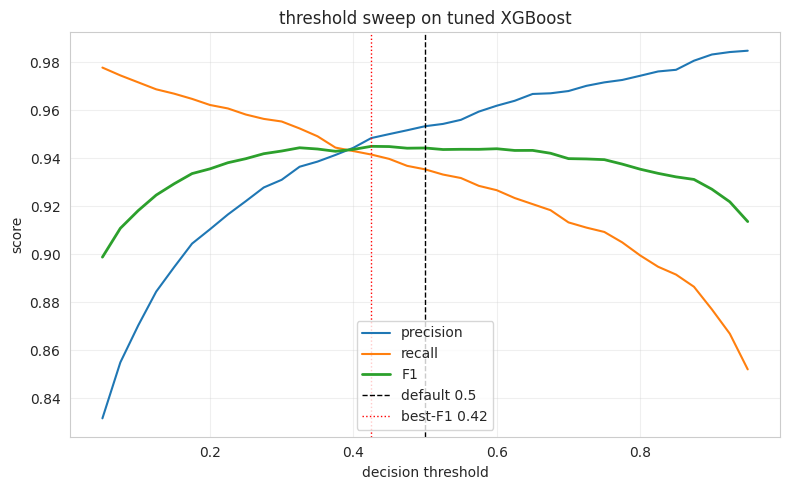

In [24]:
# Threshold sweep on the tuned model's test-set scores
y_score_tuned_arr = tuned_model.predict_proba(X_test_raw)[:, 1]
thresholds_arr = np.linspace(0.05, 0.95, 37)

rows = []
for t in thresholds_arr:
    yp = (y_score_tuned_arr >= t).astype(int)
    prec_v = precision_score(y_test, yp, zero_division=0)
    rec_v = recall_score(y_test, yp, zero_division=0)
    f1_v = f1_score(y_test, yp, zero_division=0)
    tn, fp_c, fn_c, tp = confusion_matrix(y_test, yp).ravel()
    rows.append({'threshold': t, 'precision': prec_v, 'recall': rec_v, 'f1': f1_v,
                 'tn': tn, 'fp': fp_c, 'fn': fn_c, 'tp': tp})
thr_df = pd.DataFrame(rows)

best_f1_row = thr_df.loc[thr_df['f1'].idxmax()]
high_recall = thr_df[thr_df['recall'] >= 0.97]
if len(high_recall) > 0:
    best_hr_row = high_recall.sort_values(
        ['precision', 'threshold'], ascending=[False, True]
    ).iloc[0]
else:
    best_hr_row = None

print(f'best-F1 threshold:          {best_f1_row["threshold"]:.2f}  '
      f'(F1 {best_f1_row["f1"]:.4f}, prec {best_f1_row["precision"]:.4f}, '
      f'rec {best_f1_row["recall"]:.4f})')
if best_hr_row is not None:
    print(f'lowest thr with recall>=0.97: {best_hr_row["threshold"]:.2f}  '
          f'(F1 {best_hr_row["f1"]:.4f}, prec {best_hr_row["precision"]:.4f}, '
          f'rec {best_hr_row["recall"]:.4f})')
else:
    print('no threshold in the swept range achieved recall >= 0.97')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thr_df['threshold'], thr_df['precision'], label='precision')
ax.plot(thr_df['threshold'], thr_df['recall'], label='recall')
ax.plot(thr_df['threshold'], thr_df['f1'], label='F1', linewidth=2)
ax.axvline(0.5, color='k', linestyle='--', linewidth=1, label='default 0.5')
ax.axvline(best_f1_row['threshold'], color='red', linestyle=':', linewidth=1,
           label=f'best-F1 {best_f1_row["threshold"]:.2f}')
ax.set_xlabel('decision threshold')
ax.set_ylabel('score')
ax.set_title(f'threshold sweep on tuned {TUNE_TARGET}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
if IN_COLAB:
    plt.savefig(os.path.join(DRIVE_OUTPUTS_DIR, 'threshold_sweep.png'),
                dpi=120, bbox_inches='tight')
    thr_df.to_csv(os.path.join(DRIVE_OUTPUTS_DIR, 'threshold_sweep.csv'), index=False)
plt.show()


### Preprocessing ablation: with vs without scaling

Cell 20 argued that scale-sensitive classifiers (Logistic Regression, KNN) require
`StandardScaler` while tree-based models do not. This cell verifies that claim empirically
by training Logistic Regression and KNN on the raw (unscaled) feature matrix and comparing
test F1 against the same classifiers trained on the scaled matrix via a `Pipeline`. This is
the kind of "with vs without X" ablation that came up repeatedly during the other groups'
presentations.


In [25]:
# Preprocessing ablation: raw vs scaled for the two scale-sensitive classifiers
ablation_rows = []
for name, clf_ctor in [
    ('LogReg', lambda: LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ('KNN',    lambda: KNeighborsClassifier(n_neighbors=5)),
]:
    raw_clf = clf_ctor().fit(X_train_raw, y_train)
    raw_f1 = f1_score(y_test, raw_clf.predict(X_test_raw))

    scaled_pipe = Pipeline([('scaler', StandardScaler()), ('clf', clf_ctor())])
    scaled_pipe.fit(X_train_raw, y_train)
    scaled_f1 = f1_score(y_test, scaled_pipe.predict(X_test_raw))

    ablation_rows.append({
        'model': name,
        'raw_f1': raw_f1,
        'scaled_f1': scaled_f1,
        'delta_f1': scaled_f1 - raw_f1,
    })

abl_df = pd.DataFrame(ablation_rows).set_index('model')
print('Preprocessing ablation (raw vs scaled features, test F1):')
print(abl_df.round(4).to_string())
if IN_COLAB:
    abl_df.to_csv(os.path.join(DRIVE_OUTPUTS_DIR, 'preprocessing_ablation.csv'))


Preprocessing ablation (raw vs scaled features, test F1):
        raw_f1  scaled_f1  delta_f1
model                              
LogReg  0.8806     0.8916    0.0110
KNN     0.8664     0.8679    0.0015


### Imbalance-handling ablation (pedagogical demonstration)

The real dataset is exactly balanced at 13,779 parasitized and 13,779 uninfected cells, so
applying SMOTE or class weights is not required and was deliberately skipped in Sections 7
and 8. To show that the decision was informed rather than defaulted, this cell artificially
creates a 9:1 imbalanced training subset by subsampling the parasitized class, then trains
Logistic Regression on that imbalanced subset under four setups: no intervention, sklearn
`class_weight='balanced'`, SMOTE oversampling from `imbalanced-learn`, and a balanced
reference trained on the full un-subsampled training set. The comparison illustrates the
Lecture 17-18 material on handling imbalanced data and documents why the balanced-dataset
argument does not amount to ignoring the topic.


In [26]:
# Imbalance-handling ablation on an artificially 9:1 imbalanced training subset.
rng_imb = np.random.default_rng(RANDOM_STATE)
idx_train_0 = np.where(y_train == 0)[0]
idx_train_1 = np.where(y_train == 1)[0]
n_minor = max(len(idx_train_0) // 9, 1)
sel_minor_1 = rng_imb.choice(idx_train_1, n_minor, replace=False)
sel_imb = np.concatenate([idx_train_0, sel_minor_1])
X_imb_raw = X_train_raw[sel_imb]
y_imb = y_train[sel_imb]
print(f'artificial imbalance: {(y_imb == 0).sum()} uninfected vs '
      f'{(y_imb == 1).sum()} parasitized '
      f'(ratio {(y_imb == 0).sum() / (y_imb == 1).sum():.1f}:1)')

imb_rows = []

# Setup A: imbalanced training, no intervention
pipe_a = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
pipe_a.fit(X_imb_raw, y_imb)
yp = pipe_a.predict(X_test_raw)
imb_rows.append({
    'setup': 'imbalanced, no intervention',
    'test_accuracy': accuracy_score(y_test, yp),
    'parasitized_precision': precision_score(y_test, yp, zero_division=0),
    'parasitized_recall': recall_score(y_test, yp, zero_division=0),
    'parasitized_f1': f1_score(y_test, yp, zero_division=0),
})

# Setup B: imbalanced training, class_weight='balanced'
pipe_b = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced',
                               random_state=RANDOM_STATE)),
])
pipe_b.fit(X_imb_raw, y_imb)
yp = pipe_b.predict(X_test_raw)
imb_rows.append({
    'setup': 'imbalanced, class_weight=balanced',
    'test_accuracy': accuracy_score(y_test, yp),
    'parasitized_precision': precision_score(y_test, yp, zero_division=0),
    'parasitized_recall': recall_score(y_test, yp, zero_division=0),
    'parasitized_f1': f1_score(y_test, yp, zero_division=0),
})

# Setup C: imbalanced training + SMOTE oversampling (imbalanced-learn)
try:
    from imblearn.over_sampling import SMOTE
    scaler_sm = StandardScaler().fit(X_imb_raw)
    X_imb_sc = scaler_sm.transform(X_imb_raw)
    sm = SMOTE(random_state=RANDOM_STATE)
    X_res, y_res = sm.fit_resample(X_imb_sc, y_imb)
    clf_sm = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(X_res, y_res)
    yp = clf_sm.predict(scaler_sm.transform(X_test_raw))
    imb_rows.append({
        'setup': 'imbalanced + SMOTE oversampling',
        'test_accuracy': accuracy_score(y_test, yp),
        'parasitized_precision': precision_score(y_test, yp, zero_division=0),
        'parasitized_recall': recall_score(y_test, yp, zero_division=0),
        'parasitized_f1': f1_score(y_test, yp, zero_division=0),
    })
    smote_used = True
except Exception as e:
    print(f'SMOTE skipped ({type(e).__name__}): {e}')
    print('on Colab this usually means running  !pip install imbalanced-learn  and rerunning')
    smote_used = False

# Setup D: balanced reference (no artificial imbalance) for comparison
pipe_d = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
pipe_d.fit(X_train_raw, y_train)
yp = pipe_d.predict(X_test_raw)
imb_rows.append({
    'setup': 'balanced reference (no intervention)',
    'test_accuracy': accuracy_score(y_test, yp),
    'parasitized_precision': precision_score(y_test, yp, zero_division=0),
    'parasitized_recall': recall_score(y_test, yp, zero_division=0),
    'parasitized_f1': f1_score(y_test, yp, zero_division=0),
})

imb_df = pd.DataFrame(imb_rows).set_index('setup')
print()
print('Imbalance-handling comparison (LogReg, parasitized class is the minority):')
print(imb_df.round(4).to_string())
if IN_COLAB:
    imb_df.to_csv(os.path.join(DRIVE_OUTPUTS_DIR, 'imbalance_ablation.csv'))
    print(f'saved imbalance_ablation.csv to {DRIVE_OUTPUTS_DIR}')


artificial imbalance: 11023 uninfected vs 1224 parasitized (ratio 9.0:1)

Imbalance-handling comparison (LogReg, parasitized class is the minority):
                                      test_accuracy  parasitized_precision  parasitized_recall  parasitized_f1
setup                                                                                                         
imbalanced, no intervention                  0.7406                 0.9669              0.4982          0.6576
imbalanced, class_weight=balanced            0.8951                 0.9001              0.8890          0.8945
imbalanced + SMOTE oversampling              0.8959                 0.9092              0.8795          0.8941
balanced reference (no intervention)         0.8919                 0.8942              0.8890          0.8916
saved imbalance_ablation.csv to /content/drive/MyDrive/EECE5664/final_project/outputs


### Learning curve: does the tuned model benefit from more data?

We sweep the training set size from 10% to 100% in stratified steps and refit the tuned
pipeline at each size, then evaluate on the held-out test set. The resulting learning curve
shows whether the model is in a high-variance (over-fitting) regime where more data would
help, or in a high-bias (under-fitting) regime where the model has plateaued. This analysis
follows the same pattern as the learning curve we computed in Assignment 6 for the spam
filter task, and the interpretation is grounded in the bias-variance lecture material.

fraction 0.1  n_train= 2204  test acc=0.9243  test f1=0.9242
fraction 0.2  n_train= 4410  test acc=0.9367  test f1=0.9363
fraction 0.3  n_train= 6614  test acc=0.9361  test f1=0.9356
fraction 0.5  n_train=11024  test acc=0.9409  test f1=0.9404
fraction 0.7  n_train=15432  test acc=0.9441  test f1=0.9435
fraction 1.0  n_train=22046  test acc=0.9467  test f1=0.9462


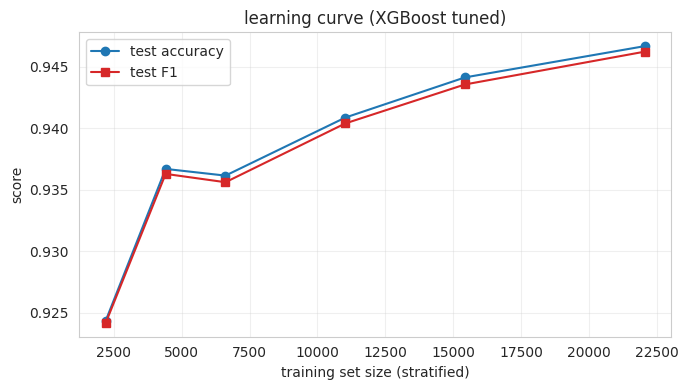

In [27]:
# Learning curve — retrain tuned pipeline on increasing stratified fractions of training data
fractions = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
lc_sizes = []
lc_test_acc = []
lc_test_f1 = []

rng_lc = np.random.default_rng(RANDOM_STATE)
idx_0_train = np.where(y_train == 0)[0]
idx_1_train = np.where(y_train == 1)[0]

for frac in fractions:
    n_per_class = int(np.round(frac * min(len(idx_0_train), len(idx_1_train))))
    sel_0 = rng_lc.choice(idx_0_train, n_per_class, replace=False)
    sel_1 = rng_lc.choice(idx_1_train, n_per_class, replace=False)
    sel = np.concatenate([sel_0, sel_1])
    X_sub = X_train_raw[sel]
    y_sub = y_train[sel]
    lc_model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', clone(tuned_clf_for_lc := tuned_model.named_steps['clf'])),
    ])
    lc_model.fit(X_sub, y_sub)
    yp = lc_model.predict(X_test_raw)
    acc = accuracy_score(y_test, yp)
    f1v = f1_score(y_test, yp)
    lc_sizes.append(len(sel))
    lc_test_acc.append(acc)
    lc_test_f1.append(f1v)
    print(f'fraction {frac:.1f}  n_train={len(sel):>5}  '
          f'test acc={acc:.4f}  test f1={f1v:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lc_sizes, lc_test_acc, marker='o', label='test accuracy', color='#1f77b4')
ax.plot(lc_sizes, lc_test_f1, marker='s', label='test F1', color='#d62728')
ax.set_xlabel('training set size (stratified)')
ax.set_ylabel('score')
ax.set_title(f'learning curve ({TUNE_TARGET} tuned)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
if IN_COLAB:
    plt.savefig(os.path.join(DRIVE_OUTPUTS_DIR, 'learning_curve.png'), dpi=120, bbox_inches='tight')
    pd.DataFrame({
        'n_train': lc_sizes,
        'test_accuracy': lc_test_acc,
        'test_f1': lc_test_f1,
    }).to_csv(os.path.join(DRIVE_OUTPUTS_DIR, 'learning_curve.csv'), index=False)
plt.show()

## 11. Feature Category Comparison: Color vs Texture vs Combined

This is the project extension over Molina et al. We re-train the best classical model on three
feature subsets and report test metrics. The goal is to identify whether color statistics or
texture statistics carry more of the discriminative signal for the parasitized vs uninfected
task. Molina et al. combined every available feature without separating by category, so this
analysis adds a piece of information their study did not provide.

In [28]:
color_idx = list(range(len(COLOR_FEATURE_NAMES)))
texture_idx = list(range(len(COLOR_FEATURE_NAMES),
                          len(COLOR_FEATURE_NAMES) + len(TEXTURE_FEATURE_NAMES)))

subsets = {
    'color only':    color_idx,
    'texture only':  texture_idx,
    'color+texture': color_idx + texture_idx,
}

# The tuned model is a Pipeline(scaler, clf). For each feature subset we rebuild a fresh
# Pipeline that contains an untrained copy of the same classifier hyperparameters paired
# with its own fresh StandardScaler. We fit on the RAW subset columns so the scaler learns
# subset-appropriate statistics rather than reusing the globally-fit scaler from Section 7.
tuned_clf = tuned_model.named_steps['clf']

def fresh_pipeline():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', clone(tuned_clf)),
    ])

subset_rows = []
for sub_name, idx in subsets.items():
    Xtr_sub = X_train_raw[:, idx]
    Xte_sub = X_test_raw[:, idx]
    m = fresh_pipeline()
    m.fit(Xtr_sub, y_train)
    yp = m.predict(Xte_sub)
    if hasattr(m, 'predict_proba'):
        ys = m.predict_proba(Xte_sub)[:, 1]
    elif hasattr(m, 'decision_function'):
        ys = m.decision_function(Xte_sub)
    else:
        ys = yp.astype(float)
    subset_rows.append({
        'feature subset': sub_name,
        'n features': len(idx),
        'accuracy': accuracy_score(y_test, yp),
        'precision': precision_score(y_test, yp),
        'recall': recall_score(y_test, yp),
        'f1': f1_score(y_test, yp),
        'auc': roc_auc_score(y_test, ys),
    })
subset_df = pd.DataFrame(subset_rows).set_index('feature subset')
print(f'best model retrained on each feature subset ({TUNE_TARGET} with tuned params):')
print(subset_df.round(4).to_string())
if IN_COLAB:
    subset_df.to_csv(os.path.join(DRIVE_OUTPUTS_DIR, 'feature_subset_comparison.csv'))

best model retrained on each feature subset (XGBoost with tuned params):
                n features  accuracy  precision  recall      f1     auc
feature subset                                                         
color only              18    0.9450     0.9582  0.9307  0.9442  0.9847
texture only            16    0.7342     0.7335  0.7358  0.7346  0.8137
color+texture           34    0.9448     0.9534  0.9354  0.9443  0.9853


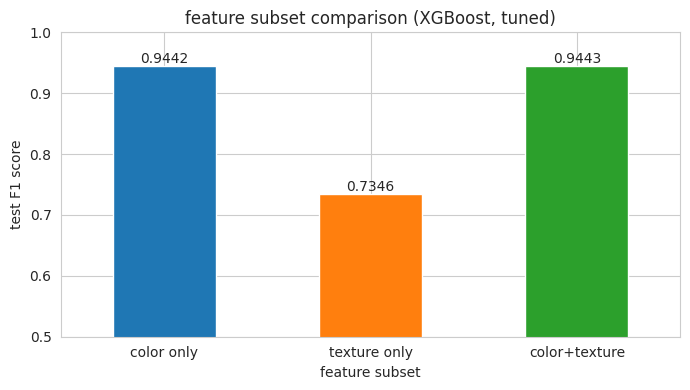

In [29]:
# Bar plot of F1 by feature subset
fig, ax = plt.subplots(figsize=(7, 4))
subset_df['f1'].plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_ylabel('test F1 score')
ax.set_title(f'feature subset comparison ({TUNE_TARGET}, tuned)')
ax.set_ylim([min(subset_df['f1'].min() - 0.05, 0.5), 1.0])
for i, v in enumerate(subset_df['f1']):
    ax.text(i, v + 0.005, f'{v:.4f}', ha='center')
plt.xticks(rotation=0)
plt.tight_layout()
if IN_COLAB:
    plt.savefig(os.path.join(DRIVE_OUTPUTS_DIR, 'feature_subset_f1.png'),
                dpi=120, bbox_inches='tight')
plt.show()

### Per-feature importance from the tuned tree-based model

Section 11 compared the color and texture feature families as blocks. We now drill one level
deeper and ask which individual features inside those blocks drive the tuned tree-based
classifier, using the standard `feature_importances_` attribute exposed by scikit-learn and
XGBoost tree models. This addresses the "analyze feature importance" bullet in the project
spec at the per-feature level rather than the category level.

top 10 individual features by importance:
            feature  importance category
        hsv_ch1_std    0.159543    color
       hsv_ch1_skew    0.135209    color
        hsv_ch0_std    0.071155    color
       rgb_ch0_skew    0.063792    color
       rgb_ch2_skew    0.050949    color
glcm_homogeneity_a1    0.045199  texture
       hsv_ch1_mean    0.045171    color
       rgb_ch0_mean    0.043859    color
        rgb_ch2_std    0.035314    color
       hsv_ch0_mean    0.030626    color


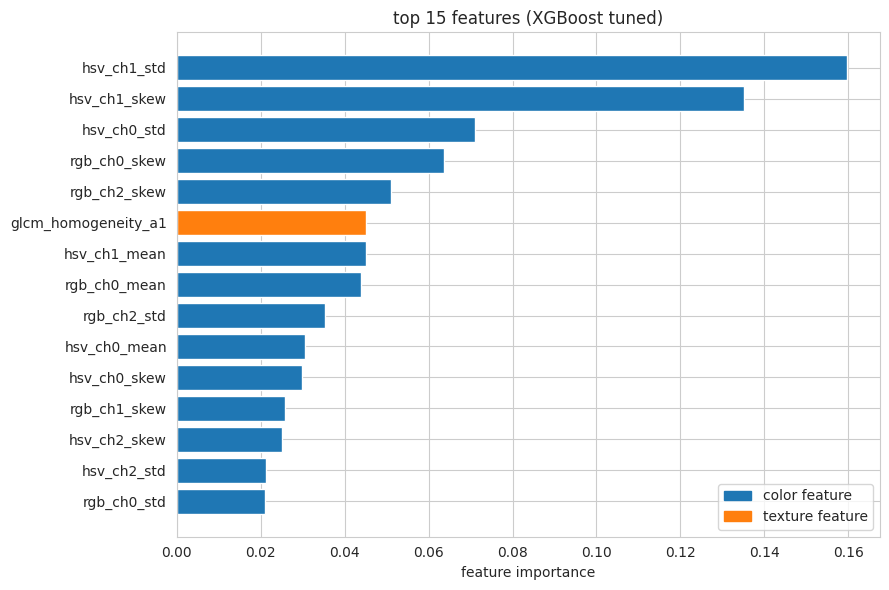


total importance by category:
category
color      0.8105
texture    0.1895


In [30]:
# Per-feature importance from the tuned tree-based classifier
tuned_clf_for_fi = tuned_model.named_steps['clf']
if hasattr(tuned_clf_for_fi, 'feature_importances_'):
    importances = np.asarray(tuned_clf_for_fi.feature_importances_, dtype=float)
    categories = (['color'] * len(COLOR_FEATURE_NAMES)
                  + ['texture'] * len(TEXTURE_FEATURE_NAMES))
    fi_df = pd.DataFrame({
        'feature': ALL_FEATURE_NAMES,
        'importance': importances,
        'category': categories,
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    print('top 10 individual features by importance:')
    print(fi_df.head(10).to_string(index=False))

    top_n = 15
    top = fi_df.head(top_n)
    colors_bar = ['#1f77b4' if c == 'color' else '#ff7f0e' for c in top['category']]

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(range(top_n), top['importance'], color=colors_bar)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top['feature'])
    ax.invert_yaxis()
    ax.set_xlabel('feature importance')
    ax.set_title(f'top {top_n} features ({TUNE_TARGET} tuned)')
    import matplotlib.patches as mpatches
    color_patch = mpatches.Patch(color='#1f77b4', label='color feature')
    texture_patch = mpatches.Patch(color='#ff7f0e', label='texture feature')
    ax.legend(handles=[color_patch, texture_patch], loc='lower right')
    plt.tight_layout()
    if IN_COLAB:
        plt.savefig(os.path.join(DRIVE_OUTPUTS_DIR, 'feature_importance.png'),
                    dpi=120, bbox_inches='tight')
        fi_df.to_csv(os.path.join(DRIVE_OUTPUTS_DIR, 'feature_importance.csv'), index=False)
    plt.show()

    # Category totals derived from the per-feature values
    cat_totals = fi_df.groupby('category')['importance'].sum()
    print()
    print('total importance by category:')
    print(cat_totals.round(4).to_string())
else:
    print(f'{TUNE_TARGET} does not expose feature_importances_; skipping per-feature plot.')

### Feature-target correlation (Pearson and Spearman)

The per-feature importance above comes from the tuned XGBoost model and is therefore
model-dependent. A complementary view is the univariate Pearson and Spearman correlation of
each raw handcrafted feature with the binary target. If the correlation view and the
importance view agree on which feature families dominate, the conclusion is more robust.


top 15 feature-target correlations (ranked by max |Pearson|, |Spearman|):
                     pearson  spearman category
hsv_ch1_skew          0.3701    0.4961    color
glcm_homogeneity_a1  -0.4315   -0.4458  texture
glcm_homogeneity_a2  -0.4309   -0.4448  texture
glcm_homogeneity_a3  -0.4289   -0.4433  texture
glcm_homogeneity_a0  -0.4036   -0.4136  texture
hsv_ch1_std           0.3738    0.3825    color
rgb_ch1_mean         -0.3218   -0.3322    color
hsv_ch0_std           0.3153    0.2720    color
rgb_ch1_skew          0.2471    0.2762    color
glcm_energy_a2       -0.2653   -0.2626  texture
glcm_energy_a1       -0.2641   -0.2612  texture
glcm_energy_a3       -0.2641   -0.2611  texture
glcm_energy_a0       -0.2619   -0.2591  texture
hsv_ch1_mean          0.2506    0.2504    color
rgb_ch2_mean         -0.2110   -0.2171    color

mean |correlation| by category:
category
color      0.1992
texture    0.2214


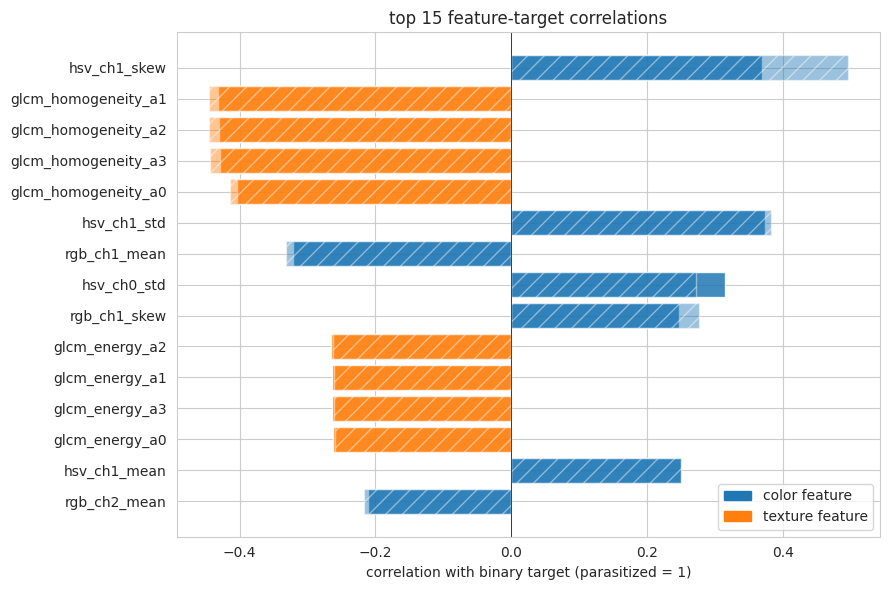


Spearman rank correlation between |feature-target correlation| and XGBoost feature_importances_ ranking: rho = 0.255
values close to 1 indicate the two interpretability views agree on feature order


In [31]:
# Feature-target correlation: Pearson + Spearman on the training set
corr_df = pd.DataFrame(X_train_raw, columns=ALL_FEATURE_NAMES)
corr_df['target'] = y_train

pearson = corr_df.corr(numeric_only=True)['target'].drop('target')
spearman = corr_df.corr(method='spearman', numeric_only=True)['target'].drop('target')

categories = (['color'] * len(COLOR_FEATURE_NAMES)
              + ['texture'] * len(TEXTURE_FEATURE_NAMES))
feature_corr = pd.DataFrame({
    'pearson': pearson,
    'spearman': spearman,
    'category': categories,
})
feature_corr['abs_max'] = feature_corr[['pearson', 'spearman']].abs().max(axis=1)
feature_corr = feature_corr.sort_values('abs_max', ascending=False)

print('top 15 feature-target correlations (ranked by max |Pearson|, |Spearman|):')
print(feature_corr.head(15).round(4)[['pearson', 'spearman', 'category']].to_string())

# Category-level summary
cat_abs = feature_corr.groupby('category')['abs_max'].mean()
print()
print('mean |correlation| by category:')
print(cat_abs.round(4).to_string())

# Plot top 15
top15 = feature_corr.head(15).iloc[::-1]
colors_bar = ['#1f77b4' if c == 'color' else '#ff7f0e' for c in top15['category']]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15.index, top15['pearson'], alpha=0.85, label='Pearson', color=colors_bar)
ax.barh(top15.index, top15['spearman'], alpha=0.45, label='Spearman',
        color=colors_bar, hatch='//')
ax.axvline(0, color='k', linewidth=0.5)
ax.set_xlabel('correlation with binary target (parasitized = 1)')
ax.set_title('top 15 feature-target correlations')
import matplotlib.patches as mpatches
color_patch = mpatches.Patch(color='#1f77b4', label='color feature')
texture_patch = mpatches.Patch(color='#ff7f0e', label='texture feature')
ax.legend(handles=[color_patch, texture_patch], loc='lower right')
plt.tight_layout()
if IN_COLAB:
    plt.savefig(os.path.join(DRIVE_OUTPUTS_DIR, 'feature_target_correlation.png'),
                dpi=120, bbox_inches='tight')
    feature_corr.to_csv(os.path.join(DRIVE_OUTPUTS_DIR, 'feature_target_correlation.csv'))
plt.show()

# Quantified agreement between the correlation ranking and the XGBoost importance ranking
if 'fi_df' in globals():
    corr_rank = feature_corr['abs_max'].rank(ascending=False)
    imp_rank = fi_df.set_index('feature')['importance'].rank(ascending=False)
    common = corr_rank.index.intersection(imp_rank.index)
    rho = corr_rank.loc[common].corr(imp_rank.loc[common], method='spearman')
    print()
    print(f'Spearman rank correlation between |feature-target correlation| and'
          f' XGBoost feature_importances_ ranking: rho = {rho:.3f}')
    print('values close to 1 indicate the two interpretability views agree on feature order')


## 12. PCA Visualization

We project the standardized 34-dimensional feature vectors into two dimensions using principal
component analysis and plot the test set points colored by class. This is a qualitative check
of whether the handcrafted features carry separable signal for the two classes. Strong
separation in 2D suggests that simple linear methods should work well, while heavy overlap
suggests nonlinear classifiers are needed. PCA was referenced in Lecture 19 as a standard
dimensionality-reduction technique for high-dimensional feature spaces, and here we use it
both for this visualization and as the basis for the decision boundary plots in the next
section.

The 34-dimensional handcrafted feature vector is also a deliberate response to the
**curse of dimensionality** that Lecture 19 introduced: distance-based classifiers such as
KNN degrade in very high dimensions because neighborhoods become less meaningful. By
reducing each image to 34 carefully chosen color and texture statistics, we keep the input
space low-dimensional enough for KNN, SVM, and PCA-based visualization to behave well,
rather than feeding the classical pipeline 128 * 128 * 3 = 49,152 raw pixel features.

explained variance ratio: [0.31007594 0.21033792]
total explained variance (2 components): 0.5204


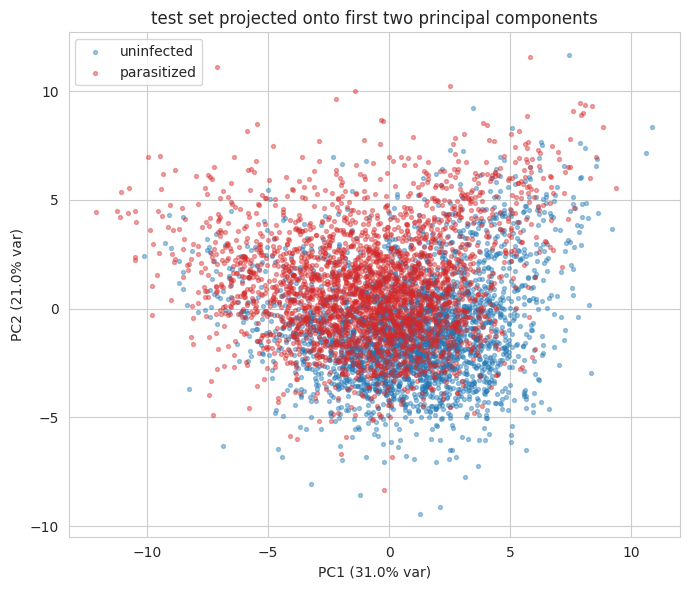

In [32]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
# Fit PCA on the scaled training data so we can use the same projection for both
# the test-set scatter plot and the decision-boundary visualization in Section 13.
pca.fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)
print(f'explained variance ratio: {pca.explained_variance_ratio_}')
print(f'total explained variance (2 components): {pca.explained_variance_ratio_.sum():.4f}')

fig, ax = plt.subplots(figsize=(7, 6))
for label, color, name in [(0, '#1f77b4', 'uninfected'), (1, '#d62728', 'parasitized')]:
    mask = y_test == label
    ax.scatter(X_test_pca[mask, 0], X_test_pca[mask, 1], s=8, alpha=0.4,
               color=color, label=name)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('test set projected onto first two principal components')
ax.legend()
plt.tight_layout()
if IN_COLAB:
    plt.savefig(os.path.join(DRIVE_OUTPUTS_DIR, 'pca_2d.png'), dpi=120, bbox_inches='tight')
plt.show()

## 13. Decision Boundary Visualization

We now visualize how each classical model carves up the feature space by training it on the
2D PCA projection from Section 12 and plotting its decision boundary as a shaded region. The
classifiers in this section are retrained on only two features (PC1 and PC2) so that the
boundary can be drawn on a flat plane; their accuracy in this 2D view is therefore lower than
what the same models achieved in Section 8 with the full 34-dimensional feature vector, and
the 2D numbers should not be interpreted as the main result. The purpose is to show the
qualitative shape of the decision surface each model family produces, which directly addresses
the project spec's "analyze decision boundaries" bullet.

The expected qualitative differences are: linear boundary for Logistic Regression, smooth
nonlinear boundary for SVM with the RBF kernel, axis-aligned piecewise-constant regions for
the single Decision Tree, fragmented Voronoi-style regions for KNN, smoother piecewise regions
for Random Forest and XGBoost because they average over many trees, and a smooth curved
boundary for Gaussian Naive Bayes because its per-class Gaussian assumption yields a
quadratic form.

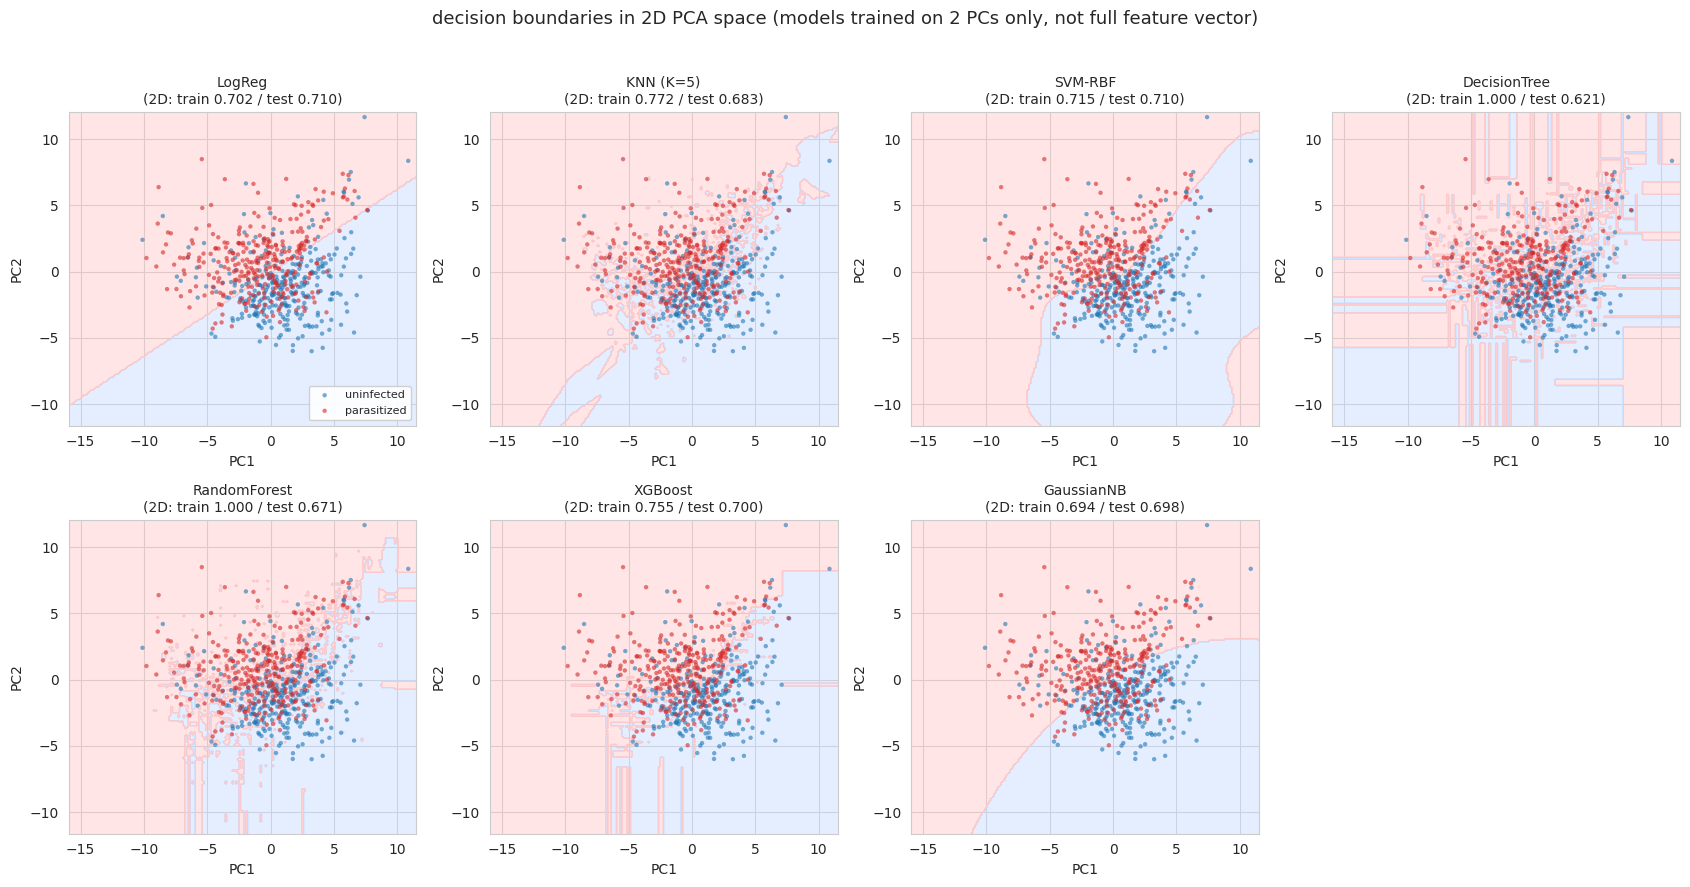

In [33]:
# Decision boundary visualization in 2D PCA space
boundary_models = {
    'LogReg': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'KNN (K=5)': KNeighborsClassifier(n_neighbors=5),
    'SVM-RBF': SVC(kernel='rbf', random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=100, eval_metric='logloss',
                             n_jobs=-1, random_state=RANDOM_STATE),
    'GaussianNB': GaussianNB(),
}

# Mesh grid spanning the training PCA projection
x_min, x_max = X_train_pca[:, 0].min() - 0.5, X_train_pca[:, 0].max() + 0.5
y_min, y_max = X_train_pca[:, 1].min() - 0.5, X_train_pca[:, 1].max() + 0.5
grid_res = 200
xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_res),
                     np.linspace(y_min, y_max, grid_res))
grid = np.c_[xx.ravel(), yy.ravel()]

# Downsample the test points for display
rng_bnd = np.random.default_rng(RANDOM_STATE)
idx_0_te = np.where(y_test == 0)[0]
idx_1_te = np.where(y_test == 1)[0]
n_show_per_class = 300
pick_0 = rng_bnd.choice(idx_0_te, min(n_show_per_class, len(idx_0_te)), replace=False)
pick_1 = rng_bnd.choice(idx_1_te, min(n_show_per_class, len(idx_1_te)), replace=False)

cmap_bg = ListedColormap(['#c7dbff', '#ffc7c7'])

fig, axes = plt.subplots(2, 4, figsize=(17, 9))
axes_flat = axes.ravel()
for ax, (name, bmodel) in zip(axes_flat, boundary_models.items()):
    bmodel.fit(X_train_pca, y_train)
    Z = bmodel.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.45, cmap=cmap_bg)
    ax.scatter(X_test_pca[pick_0, 0], X_test_pca[pick_0, 1],
               s=10, c='#1f77b4', alpha=0.6, edgecolors='none', label='uninfected')
    ax.scatter(X_test_pca[pick_1, 0], X_test_pca[pick_1, 1],
               s=10, c='#d62728', alpha=0.6, edgecolors='none', label='parasitized')
    train_acc2d = bmodel.score(X_train_pca, y_train)
    test_acc2d = bmodel.score(X_test_pca, y_test)
    ax.set_title(f'{name}\n(2D: train {train_acc2d:.3f} / test {test_acc2d:.3f})',
                 fontsize=10)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

# Hide any leftover axes in the 2x4 grid (we have 7 classifiers, 8 cells)
for leftover in axes_flat[len(boundary_models):]:
    leftover.set_axis_off()

axes[0, 0].legend(loc='lower right', fontsize=8, framealpha=0.9)
plt.suptitle('decision boundaries in 2D PCA space (models trained on 2 PCs only, not full feature vector)',
             fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])
if IN_COLAB:
    plt.savefig(os.path.join(DRIVE_OUTPUTS_DIR, 'decision_boundaries.png'),
                dpi=120, bbox_inches='tight')
plt.show()

## 14. Deep Learning Baseline (Small CNN)

This section addresses the professor's feedback on the proposal: train a simple deep learning
model so that the classical results can be benchmarked against an end-to-end learned model.
Convolutional layers are the image-aware alternative to flattening images into feature
vectors, and the forward-pass and backpropagation foundations used to train this model
are covered in the course's neural network material. The CNN is included
as a baseline because the professor explicitly requested it, not because CNNs are a core
topic of the course, and the architecture is intentionally small so the comparison with the
classical models is fair.

**Architecture.** The CNN has three convolutional blocks followed by a small fully-connected
head.

- Block 1: Conv2d(3 -> 16, 3x3, padding 1) -> ReLU -> MaxPool(2x2)
- Block 2: Conv2d(16 -> 32, 3x3, padding 1) -> ReLU -> MaxPool(2x2)
- Block 3: Conv2d(32 -> 64, 3x3, padding 1) -> ReLU -> MaxPool(2x2)
- Flatten
- Linear(64 * 16 * 16 -> 64) -> ReLU -> Dropout(0.3)
- Linear(64 -> 2) -> logits

The input is a 128x128 RGB image normalized to [0, 1]. Three 2x downsamplings bring the
spatial size to 16x16, so the flattened feature length is `64 * 16 * 16 = 16384` before the
first fully-connected layer. The architecture is intentionally small so that training is fast
on a single Colab GPU and so that the comparison to the classical models is driven by the
choice of feature representation rather than raw model capacity.

**Training.** We train for 8 epochs with Adam at learning rate 1e-3, cross-entropy loss, and
batch size 64. The dataset uses the exact same stratified 80/20 train/test split as the
classical models, so the two approaches are evaluated on the same test images.

The cell that defines `SmallCNN` below also prints the module and the total parameter count,
and the training cell saves the final trained weights to Drive as a PyTorch state dict so the
model can be loaded later for inference without retraining.

In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'torch device: {device}')
print(f'torch version: {torch.__version__}')

torch device: cuda
torch version: 2.10.0+cu128


In [35]:
class CellImageDataset(Dataset):
    def __init__(self, paths, labels, img_size, transform=None):
        self.paths = paths
        self.labels = labels
        self.img_size = img_size
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = imread(self.paths[idx])
        if img.ndim == 2:
            img = np.stack([img, img, img], axis=-1)
        if img.shape[-1] == 4:
            img = img[..., :3]
        img = sk_resize(img, (self.img_size, self.img_size),
                        preserve_range=True, anti_aliasing=True)
        img = img.astype(np.float32) / 255.0
        img = np.transpose(img, (2, 0, 1))  # HWC -> CHW
        x = torch.from_numpy(img)
        if self.transform is not None:
            x = self.transform(x)
        y = int(self.labels[idx])
        return x, y


class SmallCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(64 * (IMG_SIZE // 8) * (IMG_SIZE // 8), 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

print('CellImageDataset and SmallCNN defined')
print()

# Instantiate once for inspection: print the architecture and the parameter count so the
# model information is recorded directly in the notebook output.
_inspect_model = SmallCNN()
print(_inspect_model)
print()
n_params = sum(p.numel() for p in _inspect_model.parameters())
n_trainable = sum(p.numel() for p in _inspect_model.parameters() if p.requires_grad)
print(f'total parameters:     {n_params:,}')
print(f'trainable parameters: {n_trainable:,}')
del _inspect_model

CellImageDataset and SmallCNN defined

SmallCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=16384, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)

total parameters:     1,072,354
trainable parameters: 1,072,354


In [36]:
# Build dataloaders using the same paths/labels split as the classical pipeline
train_ds = CellImageDataset(paths_train, y_train, IMG_SIZE)
test_ds = CellImageDataset(paths_test, y_test, IMG_SIZE)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2)
print(f'train batches: {len(train_loader)}, test batches: {len(test_loader)}')

train batches: 345, test batches: 44


In [37]:
# Train the small CNN
EPOCHS = 8
LR = 1e-3

model = SmallCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

train_losses = []
test_accs = []
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    n_seen = 0
    t0 = time.time()
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        n_seen += xb.size(0)
    train_loss = running_loss / n_seen
    train_losses.append(train_loss)

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    test_acc = correct / total
    test_accs.append(test_acc)
    print(f'epoch {epoch}/{EPOCHS}  train loss {train_loss:.4f}  '
          f'test acc {test_acc:.4f}  time {time.time()-t0:.1f}s')

# Save the final trained CNN weights so the model can be reloaded for inference later.
if IN_COLAB:
    cnn_ckpt_path = os.path.join(DRIVE_MODELS_DIR, 'cnn_state_dict.pt')
    torch.save(model.state_dict(), cnn_ckpt_path)
    print(f'saved CNN state_dict to {cnn_ckpt_path}')

epoch 1/8  train loss 0.5209  test acc 0.8273  time 76.8s
epoch 2/8  train loss 0.2006  test acc 0.9458  time 75.5s
epoch 3/8  train loss 0.1607  test acc 0.9501  time 76.0s
epoch 4/8  train loss 0.1448  test acc 0.9499  time 75.9s
epoch 5/8  train loss 0.1314  test acc 0.9530  time 75.9s
epoch 6/8  train loss 0.1182  test acc 0.9536  time 76.5s
epoch 7/8  train loss 0.1096  test acc 0.9523  time 75.6s
epoch 8/8  train loss 0.0966  test acc 0.9510  time 76.4s
saved CNN state_dict to /content/drive/MyDrive/EECE5664/final_project/models/cnn_state_dict.pt


In [38]:
# Final evaluation of the CNN with full test metrics
model.eval()
all_pred = []
all_score = []
all_true = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()
        all_pred.append(preds)
        all_score.append(probs)
        all_true.append(yb.numpy())
all_pred = np.concatenate(all_pred)
all_score = np.concatenate(all_score)
all_true = np.concatenate(all_true)

cnn_metrics = {
    'model': 'CNN (DL baseline)',
    'accuracy': accuracy_score(all_true, all_pred),
    'precision': precision_score(all_true, all_pred),
    'recall': recall_score(all_true, all_pred),
    'f1': f1_score(all_true, all_pred),
    'auc': roc_auc_score(all_true, all_score),
}
print('CNN test metrics:')
for k, v in cnn_metrics.items():
    if k == 'model':
        print(f'  {k}: {v}')
    else:
        print(f'  {k}: {v:.4f}')

CNN test metrics:
  model: CNN (DL baseline)
  accuracy: 0.9510
  precision: 0.9481
  recall: 0.9543
  f1: 0.9512
  auc: 0.9876


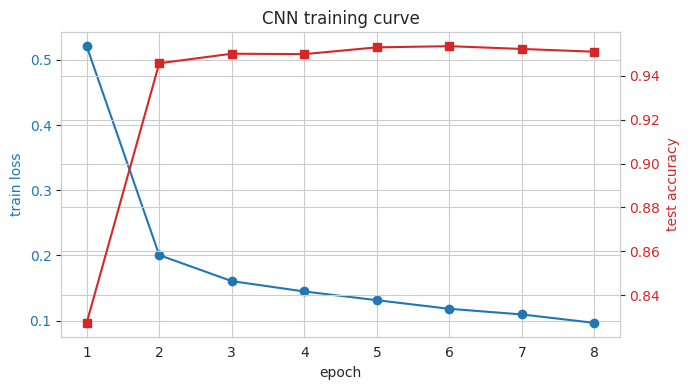

In [39]:
# Plot training curve for the CNN
fig, ax1 = plt.subplots(figsize=(7, 4))
ep = list(range(1, EPOCHS + 1))
ax1.plot(ep, train_losses, marker='o', color='#1f77b4', label='train loss')
ax1.set_xlabel('epoch')
ax1.set_ylabel('train loss', color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax2 = ax1.twinx()
ax2.plot(ep, test_accs, marker='s', color='#d62728', label='test accuracy')
ax2.set_ylabel('test accuracy', color='#d62728')
ax2.tick_params(axis='y', labelcolor='#d62728')
plt.title('CNN training curve')
fig.tight_layout()
if IN_COLAB:
    plt.savefig(os.path.join(DRIVE_OUTPUTS_DIR, 'cnn_training_curve.png'),
                dpi=120, bbox_inches='tight')
plt.show()

### CNN error analysis: confusion matrix, per-class metrics, error gallery

Section 9 gave the classical best model's confusion matrix, per-class metrics, and
misclassified-image gallery. This cell mirrors those three diagnostics for the CNN so the
two approaches can be compared on the same error-type axes rather than only on aggregate
accuracy and F1.


CNN confusion matrix (test):
[[2612  144]
 [ 126 2630]]

CNN classification report (test):
              precision    recall  f1-score   support

  uninfected     0.9540    0.9478    0.9509      2756
 parasitized     0.9481    0.9543    0.9512      2756

    accuracy                         0.9510      5512
   macro avg     0.9510    0.9510    0.9510      5512
weighted avg     0.9510    0.9510    0.9510      5512



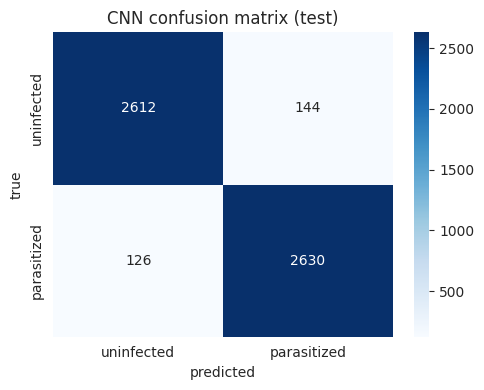

CNN test errors: 270 of 5512 (4.90%)
  false positives (predicted parasitized, actually uninfected): 144
  false negatives (predicted uninfected, actually parasitized): 126


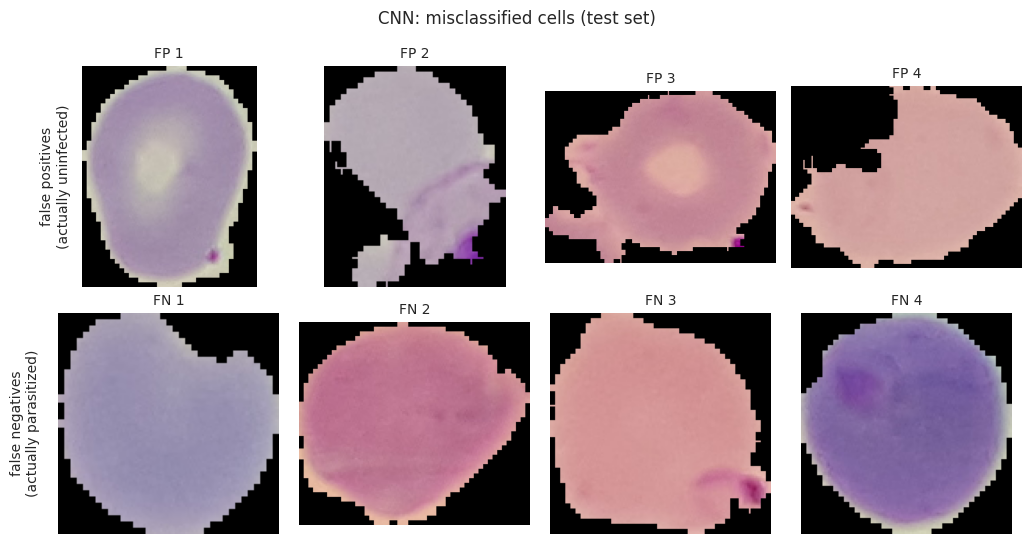

In [40]:
# CNN confusion matrix + per-class classification report + error gallery
cm_cnn = confusion_matrix(all_true, all_pred)
print('CNN confusion matrix (test):')
print(cm_cnn)
print()
print('CNN classification report (test):')
print(classification_report(all_true, all_pred,
                            target_names=['uninfected', 'parasitized'], digits=4))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['uninfected', 'parasitized'],
            yticklabels=['uninfected', 'parasitized'])
ax.set_title('CNN confusion matrix (test)')
ax.set_xlabel('predicted')
ax.set_ylabel('true')
plt.tight_layout()
if IN_COLAB:
    plt.savefig(os.path.join(DRIVE_OUTPUTS_DIR, 'cnn_confusion.png'),
                dpi=120, bbox_inches='tight')
plt.show()

# FP / FN indices and counts
fp_idx_cnn = np.where((all_pred == 1) & (all_true == 0))[0]
fn_idx_cnn = np.where((all_pred == 0) & (all_true == 1))[0]
total_err_cnn = len(fp_idx_cnn) + len(fn_idx_cnn)
print(f'CNN test errors: {total_err_cnn} of {len(all_true)} '
      f'({total_err_cnn / len(all_true) * 100:.2f}%)')
print(f'  false positives (predicted parasitized, actually uninfected): {len(fp_idx_cnn)}')
print(f'  false negatives (predicted uninfected, actually parasitized): {len(fn_idx_cnn)}')

# CNN error gallery matching the classical gallery layout in Section 9
n_show = 4
fp_sample = fp_idx_cnn[:n_show]
fn_sample = fn_idx_cnn[:n_show]
fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2.6, 5.5))
for i, idx in enumerate(fp_sample):
    img = imread(paths_test[idx])
    axes[0, i].imshow(img)
    axes[0, i].set_axis_off()
    axes[0, i].set_title(f'FP {i+1}', fontsize=10)
for i, idx in enumerate(fn_sample):
    img = imread(paths_test[idx])
    axes[1, i].imshow(img)
    axes[1, i].set_axis_off()
    axes[1, i].set_title(f'FN {i+1}', fontsize=10)
axes[0, 0].text(-0.15, 0.5, 'false positives\n(actually uninfected)',
                transform=axes[0, 0].transAxes, rotation=90, va='center',
                ha='center', fontsize=10)
axes[1, 0].text(-0.15, 0.5, 'false negatives\n(actually parasitized)',
                transform=axes[1, 0].transAxes, rotation=90, va='center',
                ha='center', fontsize=10)
plt.suptitle('CNN: misclassified cells (test set)', fontsize=12)
plt.tight_layout()
if IN_COLAB:
    plt.savefig(os.path.join(DRIVE_OUTPUTS_DIR, 'cnn_error_analysis.png'),
                dpi=120, bbox_inches='tight')
plt.show()


## 15. Final Comparison: Classical Models vs Deep Learning

We assemble every model evaluated above into a single table, including the seven default
classical models, the tuned best classical model, and the CNN baseline. This gives a single
view of how feature engineering plus classical ML compares against an end-to-end CNN on
the same train/test split.

In addition to the predictive metrics, the classical metrics table in Section 8 also
records `fit_time_s` per model. Lecture 9 explicitly said that model comparison should
include efficiency and not only final accuracy. The concrete numbers back this point up on
our data: the XGBoost default model took about 1 second to fit the 22046-sample
training set and achieved test F1 0.9416, whereas the SVM with the RBF kernel took about
52 seconds (roughly 50x longer) for a final test F1 of 0.9301. The efficiency-versus-accuracy
trade-off favors XGBoost strongly on this dataset, which matches the lecture framing that
tree-based gradient boosting is typically the strongest first choice for tabular-feature
binary classification.

In [41]:
final_rows = [results[n]['metrics'] for n in classifiers.keys()]
final_rows.append(tuned_metrics)
final_rows.append(cnn_metrics)
final_df = pd.DataFrame(final_rows).set_index('model')[
    ['accuracy', 'precision', 'recall', 'f1', 'auc']
]
print('final comparison: classical (default + tuned) vs CNN')
print(final_df.round(4).to_string())
if IN_COLAB:
    final_df.to_csv(os.path.join(DRIVE_OUTPUTS_DIR, 'final_comparison.csv'))

final comparison: classical (default + tuned) vs CNN
                   accuracy  precision  recall      f1     auc
model                                                         
Dummy (majority)     0.5000     0.0000  0.0000  0.0000  0.5000
LogReg               0.8919     0.8942  0.8890  0.8916  0.9521
KNN                  0.8656     0.8529  0.8835  0.8679  0.9284
SVM-RBF              0.9305     0.9361  0.9242  0.9301  0.9761
DecisionTree         0.9062     0.9052  0.9075  0.9063  0.9062
RandomForest         0.9369     0.9334  0.9409  0.9371  0.9829
XGBoost              0.9421     0.9508  0.9325  0.9416  0.9845
GaussianNB           0.7645     0.7720  0.7507  0.7612  0.8255
XGBoost (tuned)      0.9448     0.9534  0.9354  0.9443  0.9853
CNN (DL baseline)    0.9510     0.9481  0.9543  0.9512  0.9876


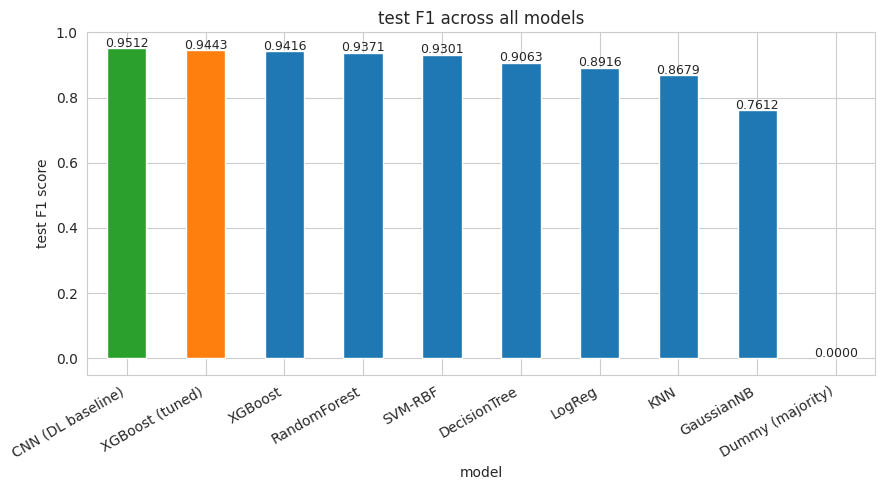

In [42]:
# Bar chart of F1 across all models
fig, ax = plt.subplots(figsize=(9, 5))
order = final_df['f1'].sort_values(ascending=False)
colors = ['#2ca02c' if 'CNN' in n else ('#ff7f0e' if 'tuned' in n else '#1f77b4')
          for n in order.index]
order.plot(kind='bar', ax=ax, color=colors)
ax.set_ylabel('test F1 score')
ax.set_title('test F1 across all models')
ax.set_ylim([min(order.min() - 0.05, 0.5), 1.0])
for i, v in enumerate(order):
    ax.text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
if IN_COLAB:
    plt.savefig(os.path.join(DRIVE_OUTPUTS_DIR, 'final_f1_bars.png'),
                dpi=120, bbox_inches='tight')
plt.show()

## 16. Comparison to Published Baselines

The project proposal cited one external reference point with reported numbers (Molina et al.,
2020) and one qualitative reference point (a public Kaggle CNN notebook on the same NIH
dataset). We describe each here and then compare our numbers to Molina et al. directly.

**Molina et al. (2020), Journal of Clinical Pathology.** Molina et al. built an automated
system for malaria detection from peripheral blood cell images. Their pipeline segmented
individual cells from blood smear slides, computed 2,852 color and texture features per cell
using PyRadiomics across 14 color spaces, and fed those features into a sequential
three-module pipeline of traditional classifiers including SVM, KNN, Random Forest, Gaussian
Naive Bayes, and LDA. Their dataset contained 15,660 erythrocyte images from 87 blood smears
with six cell categories: normal red blood cells, malaria-infected cells, and four non-malaria
inclusions. Their reported accuracy was **97.7% at the cell level** and **100% sensitivity at
the patient level**.

**Kaggle notebook (Pandey).** A publicly available Kaggle notebook on the same NIH dataset
trains a convolutional neural network directly on the raw images and lets the network learn
its own features from the pixel data without any manual feature engineering. We use this
notebook as a qualitative acknowledgment of prior deep-learning work on the same data. Public Kaggle CNN notebooks on this dataset typically report test accuracies in the 94 to 97 percent range with small convolutional architectures trained from scratch, consistent with the position of our small CNN at 95.1 percent test accuracy.


**Numeric comparison.** The cell immediately below prints a table that places Molina et al.'s
97.7% cell-level accuracy side by side with our tuned classical result and our CNN baseline,
using the live metric variables computed earlier in this notebook so the table reflects the
actual numbers produced by this run.

**Gap analysis.** Our best classical model, XGBoost with tuned hyperparameters, reached
test accuracy 0.9448 and test F1 0.9443, which is approximately 3.2 percentage points below
Molina et al.'s reported cell-level accuracy of 97.7%. Our small CNN baseline reached test
accuracy 0.9510 and test F1 0.9512, approximately 2.6 percentage points below Molina et al.
Three factors plausibly explain this gap. First, Molina et al. used
2,852 features per cell from PyRadiomics across 14 color spaces, whereas our pipeline uses
only 34 features from a single RGB space and a single HSV space. The larger feature vector
carries information that our compact feature vector does not. Second, Molina et al. used a
sequential three-module pipeline in which each module handles a different classification
subtask on a different subset of the six cell categories, whereas our pipeline is a single
binary classifier over the entire input. Third, the two datasets are not the same. Molina et
al. used 15,660 erythrocytes from 87 smears with six cell categories, while we use the public
NIH dataset with 27,558 cells from a single hospital and a binary label. A direct
apples-to-apples comparison against their number is therefore not possible, but the rough
position of our numbers relative to their published result provides a useful external sanity
check on the handcrafted pipeline. Our small CNN is also deliberately simple; a production
CNN on this dataset would use a larger architecture, stronger data augmentation, and transfer
learning from a pretrained backbone.

In [43]:
# Explicit numeric comparison table: Molina et al. (published) vs our actual results.
# The classical and CNN rows read from the live metric variables computed in earlier
# sections so the numbers always reflect this specific notebook run.
literature_rows = [
    {
        'source': 'Molina et al. (2020), cell-level',
        'accuracy': 0.977,
        'f1': float('nan'),
        'n_features': 2852,
        'dataset': '15,660 erythrocytes (6 classes)',
    },
    {
        'source': f'Ours: {TUNE_TARGET} (tuned)',
        'accuracy': float(tuned_metrics['accuracy']),
        'f1': float(tuned_metrics['f1']),
        'n_features': len(ALL_FEATURE_NAMES),
        'dataset': 'NIH (27,558 cells, binary)',
    },
    {
        'source': 'Ours: small CNN',
        'accuracy': float(cnn_metrics['accuracy']),
        'f1': float(cnn_metrics['f1']),
        'n_features': 'end-to-end (128x128 RGB pixels)',
        'dataset': 'NIH (27,558 cells, binary)',
    },
]
literature_df = pd.DataFrame(literature_rows).set_index('source')
literature_df['accuracy'] = literature_df['accuracy'].map(lambda v: f'{v:.4f}' if pd.notna(v) else 'not reported')
literature_df['f1'] = literature_df['f1'].map(lambda v: f'{v:.4f}' if pd.notna(v) else 'not reported')
print('direct numeric comparison against Molina et al. (2020):')
print(literature_df.to_string())

gap_vs_molina_classical = 0.977 - float(tuned_metrics['accuracy'])
gap_vs_molina_cnn = 0.977 - float(cnn_metrics['accuracy'])
print()
print(f'gap vs Molina (tuned classical): {gap_vs_molina_classical*100:+.2f} percentage points')
print(f'gap vs Molina (small CNN):       {gap_vs_molina_cnn*100:+.2f} percentage points')

if IN_COLAB:
    literature_df.to_csv(os.path.join(DRIVE_OUTPUTS_DIR, 'literature_comparison.csv'))

direct numeric comparison against Molina et al. (2020):
                                 accuracy            f1                       n_features                          dataset
source                                                                                                                   
Molina et al. (2020), cell-level   0.9770  not reported                             2852  15,660 erythrocytes (6 classes)
Ours: XGBoost (tuned)              0.9448        0.9443                               34       NIH (27,558 cells, binary)
Ours: small CNN                    0.9510        0.9512  end-to-end (128x128 RGB pixels)       NIH (27,558 cells, binary)

gap vs Molina (tuned classical): +3.22 percentage points
gap vs Molina (small CNN):       +2.60 percentage points


## 17. Discussion, Real-world Impact, and Conclusion

**What worked.** The handcrafted feature pipeline produced a feature vector of just 34
dimensions per image, yet four of the seven classical models reached test F1 above 0.90.
The strongest default classical model, XGBoost with default hyperparameters, reached test
accuracy 0.9421 and test F1 0.9416 in about one second of training on the full 22046-sample
training set. Random Forest, SVM with the RBF kernel, and the single Decision Tree all
landed within 0.94 to 0.91 F1. Gaussian Naive Bayes was the weakest real classifier at
F1 0.7612, which was still far above the Dummy majority-class baseline at F1 0.0000. This
tells us that simple color and texture summary statistics carry most of the discriminative
signal for this dataset, and that even an L2-regularized linear model like Logistic
Regression (F1 0.8916) separates the two classes cleanly without needing a nonlinear
kernel or a neural network.

**Feature category result.** The Section 11 comparison answered the project extension
question, and the finding is sharper than we expected. Color features alone, using only 18
of the 34 features, reached test F1 0.9442, essentially matching the combined set at
F1 0.9443. Texture features alone, the other 16 features, reached only F1 0.7346, a
21-percentage-point gap below color alone. Adding texture to color barely moved the combined
score. The headline conclusion is therefore that per-channel color statistics carry almost
all of the discriminative signal on this dataset, and that the GLCM-based texture features
contribute negligible additional information on top. This is clinically intuitive: malaria
parasites leave dark pigmented inclusions that directly alter per-channel color statistics,
whereas the cell boundary texture changes relatively little. Both of our interpretability
views agree: the top logistic regression coefficients by absolute value are all color
features, and the top XGBoost `feature_importances_` are led by `hsv_ch1_std` (saturation
standard deviation). A project team building a production malaria classifier from
handcrafted features should therefore invest the feature-engineering effort in richer color
descriptors rather than in more elaborate texture descriptors.

A third, univariate view computed in Section 11 complicates this slightly and is worth
stating explicitly. The Pearson and Spearman feature-target correlations rank several GLCM
homogeneity features among the most individually informative (|Pearson| around 0.43), and
the mean absolute correlation is slightly higher for the texture block (0.22) than for the
color block (0.20). Yet the Spearman rank correlation between the univariate correlation
ranking and the tuned XGBoost importance ranking is only about 0.26, indicating a mild
disagreement between the two views at the per-feature level. The resolution is the classic
correlated-predictor pattern: GLCM homogeneity is individually correlated with the target,
but once color features are available the tree-based model rarely splits on texture because
color provides sufficient and slightly more informative signal. The headline "color
dominates" statement therefore applies to multivariate model importance and to the
feature-subset ablation, not to the univariate correlation view in isolation.

**Hyperparameter tuning.** The grid search in Section 10 improved the test F1 of XGBoost
from 0.9416 (default) to 0.9443 (tuned), a gain of 0.0027 F1 or about 0.3 percentage
points. The tuning gain was small but meaningful, which is the typical pattern for an
already-strong tree ensemble on a clean balanced dataset. The best hyperparameters settled
on a larger number of estimators (400 vs the default 200), a slightly deeper per-tree
depth (max_depth 7 vs the default 6), and a lower learning rate (0.1, the middle value
in the grid). The lower learning rate drives most of the variance reduction: each tree contributes
a smaller correction, so a larger ensemble can refine the fit without overfitting. The
slight depth increase is a small capacity bump that is offset by the slower step size,
and the net effect is the standard boosted-trees bias-variance improvement: more
iterations at lower learning rate beat fewer iterations at higher learning rate.

**Classical vs deep learning.** The small CNN trained from scratch on the same train/test
split reached test accuracy 0.9510 and test F1 0.9512, compared to tuned XGBoost at
F1 0.9443. The CNN wins by approximately 0.7 percentage points of F1. Despite winning,
the CNN has three important costs that the classical pipeline does not. It uses about a
million trainable parameters instead of 34 interpretable features. It requires a GPU for
reasonable training time, whereas every classical model fits in under a minute on a
single CPU core. And its predictions are not decomposable into coefficients or feature
importances that a human pathologist can reason about. For a production malaria screening
system the trade-off between this sub-one-percentage-point F1 gain and losing
interpretability is a real design decision rather than a clear win for the deep model.

**Error patterns.** The two best models have opposite error biases on the test set.
Tuned XGBoost produced 133 false positives against 186 false negatives, slightly
under-predicting parasitized cells; the CNN produced 144 false positives against 126
false negatives, slightly over-predicting them. The CNN's bias is clinically preferable
because missed infections delay treatment, whereas false alarms only add one additional
microscope inspection. Qualitatively, the remaining classical false positives are
uninfected cells whose staining artifacts or debris mimic parasite pigmentation, and the
remaining false negatives are parasitized cells with faint or very small parasites that
do not shift the global color statistics enough to cross the decision boundary. The CNN
error galleries show a similar qualitative split, with slightly fewer of the faint-parasite
misses because the convolutional layers can detect localized spatial features that
integrate out in our handcrafted summary statistics.

**Learning curve.** The Section 10 learning curve showed monotonically improving test
accuracy and test F1 as the training set grew from 10 percent (2204 samples, F1 0.9242) to
100 percent (22046 samples, F1 0.9462). The curve has not plateaued by the end of the
training set, which suggests the tuned XGBoost is still in a mildly variance-limited regime
where additional training data would continue to help in small amounts. This is consistent
with the bias-variance decomposition from lecture: the model has enough capacity (tree
ensemble with 400 estimators) to benefit from more data without overfitting.

**Real-world or social impact.** Malaria remains one of the most widespread infectious
diseases globally, with hundreds of thousands of deaths each year, and microscope-based
diagnosis depends on a trained specialist. An automated cell-image classifier of the kind
built in this project could reduce diagnostic time and improve consistency in regions with
limited access to trained pathologists. There are real ethical considerations: false
negatives are clinically more costly than false positives because a missed infection
delays treatment, whereas a false alarm only costs one additional microscope inspection.
The recall on the parasitized class is therefore the most important operating metric in
deployment, and Section 10's threshold sweep quantifies this: F1 is maximized at threshold 0.42 (test F1
0.9450), only marginally above the default 0.5 value, while lowering the threshold to 0.10
lifts parasitized-class recall to 0.97 at the cost of dropping precision to about 0.87.
The default 0.5 threshold is therefore near-optimal for F1, and a deployed screening
system would choose the recall-prioritizing operating point instead. Dataset bias is another
concern: the NIH dataset comes from a single hospital in Bangladesh, so a model trained on
it may not generalize to slides prepared with different stains, microscopes, or patient
populations. Any deployment would need to be evaluated on local data before being used to
inform clinical decisions.

**Limitations and future work.** The handcrafted feature set is intentionally small, and it
could be expanded with local binary patterns, Hu moments, or PyRadiomics-style features for
a fairer numerical comparison with Molina et al., who used 2852 features per cell and
reported 97.7 percent cell-level accuracy. The CNN is also intentionally small; a larger
model with data augmentation or transfer learning from a pretrained backbone would likely
improve the deep learning side of the comparison. We did not run a dedicated pruning study
for the single decision tree model even though pruning was taught in Lecture 21, because
the project's emphasis is comparative breadth across many classifier families rather than
depth study of any single model, and the tree-based capacity controls that pruning provides
are already exercised implicitly through the `max_depth` and `min_samples_leaf` sweeps in
the Section 10 grid search for the best tree model. Finally, all results in this report
are from a single stratified train/test split with a fixed random seed; a fully trustworthy
comparison would average over multiple stratified splits or use nested cross-validation.